# Training, Ablation & Evaluation — All Datasets

## Evaluation Strategy

### Default: Stratified 80/20 hold-out

A fixed 20% test set is held out before any training. 5-fold CV runs on the remaining 80% for model selection and ablation.
Final metrics are reported on 20%.  This is the primary evaluation path because it produces an unbiased single-pass estimate on data the model never saw.


### Classifiers

| Classifier | Notes |
|-----------|-------|
| Logistic Regression | 
| **ElasticNet Logit** | 
| Random Forest | 200 trees, max_depth=6 |
| **Gradient Boosting** |
| XGBoost | 200 trees, max_depth=4 |

### Ablation options

| Variant | Features |
|---------|----------|
| Entropy only | H_sem |
| Geometry only | D_cos, D_cos_var, D_pair, M_bar |
| Entropy + Geometry | H_sem + geometry |
| All 6 geometric | All features |


## Setup

In [1]:
import sys, os, copy
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from spectral_detection.data.cleaning import GEO_FEATURES, split_analysis_domains
from spectral_detection.training import (
    run_ablation, run_cv_model_selection, evaluate_final_model,
    evaluate_cv_predictions, make_train_test_split,
    build_classifiers, ABLATION_SETS, run_per_domain_clf,
)
from spectral_detection.visualization import (
    plot_ablation_bar, plot_roc_curves, plot_ablation_roc_curves,
    plot_per_domain_clf_heatmap, plot_shap_beeswarm,
    plot_precision_recall_curve, plot_calibration_curve,
    plot_threshold_diagnostics, plot_predicted_prob_hist,
    plot_confusion_matrices, plot_logit_coefficients,
)


## Configuration

In [2]:
CSV_DIR    = '../data/temp/processed_csv/'
OUTPUT_DIR = '../data/processed/temp/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MIN_QUESTIONS_FOR_ANALYSIS = 10
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Evaluation mode ──────────────────────────────────────────────────────────
# USE_HOLDOUT = True  (default)
#   Stratified 80/20 split. CV on 80%, final metrics on held-out 20%.
#   Recommended for production estimates and when comparing many classifiers.
#
# USE_HOLDOUT = False
#   CV out-of-fold on the full dataset. Maximises statistical power at small
#   sample sizes (e.g. single-benchmark ~500q sections).
USE_HOLDOUT = True


## Load Feature DataFrames


In [3]:
feat_dfs = {}
for ds in ['defan', 'halueval', 'mmlu', 'triviaqa', 'truthfulqa']:
    feat_dfs[ds] = pd.read_csv(os.path.join(CSV_DIR, f'{ds}_features.csv'))
    rate = feat_dfs[ds]['label'].mean() * 100
    print(f'{ds:12s}: {len(feat_dfs[ds]):4d} q  hallu={rate:.1f}%')
feat_all = pd.read_csv(os.path.join(CSV_DIR, 'combined_features.csv'))
print(f'\ncombined  : {len(feat_all):4d} q  hallu={feat_all["label"].mean()*100:.1f}%')
print(f'Features  : {GEO_FEATURES}')


defan       :  500 q  hallu=79.6%
halueval    :  500 q  hallu=7.2%
mmlu        :  500 q  hallu=78.4%
triviaqa    :  500 q  hallu=41.6%
truthfulqa  :  500 q  hallu=72.0%

combined  : 2500 q  hallu=55.8%
Features  : ['H_sem', 'D_cos', 'D_cos_var', 'D_pair', 'M_bar', 'K', 'sig2_S']


---
## DEFAN


### DEFAN: Model Selection


In [4]:
if USE_HOLDOUT:
    X_tr_defan, X_te_defan, y_tr_defan, y_te_defan, _ = make_train_test_split(
        feat_dfs['defan'], random_seed=RANDOM_SEED,
    )
    df_cv_defan, best_defan = run_cv_model_selection(
        X_tr_defan, y_tr_defan, random_seed=RANDOM_SEED,
    )
else:
    df_cv_defan, best_defan = run_cv_model_selection(
        feat_dfs['defan'], random_seed=RANDOM_SEED,
    )
    X_tr_defan = None  # set below in ablation
    y_tr_defan = None
display(df_cv_defan)


Train: 400  |  Test: 100
Train hallucination rate: 79.5%
Test  hallucination rate: 80.0%
CV model selection — mode: holdout-train  |  n=400  |  hallu rate=79.5%
  Logistic Regression       | AUC=0.9235±0.0401  AP=0.9808
  ElasticNet Logit          | AUC=0.9247±0.0392  AP=0.9812
  Random Forest             | AUC=0.9228±0.0369  AP=0.9801
  Gradient Boosting         | AUC=0.9266±0.0275  AP=0.9805
  XGBoost                   | AUC=0.9209±0.0229  AP=0.9800

Best classifier: Gradient Boosting


,Classifier,CV_AUC_mean,CV_AUC_std,CV_AP_mean,CV_AP_std
3,Gradient Boosting,0.926647,0.027462,0.980527,0.008392
1,ElasticNet Logit,0.924709,0.039197,0.981224,0.009823
0,Logistic Regression,0.923537,0.040129,0.980821,0.010124
2,Random Forest,0.922799,0.036880,0.980121,0.009699
4,XGBoost,0.920867,0.022890,0.980041,0.005340


### DEFAN: Ablation


In [5]:
df_clf_defan, X_tr_defan, X_te_defan, y_tr_defan, y_te_defan = run_ablation(
    feat_dfs['defan'],
    random_seed=RANDOM_SEED,
    use_holdout=USE_HOLDOUT,
)
metric_col = 'Test_AUC' if USE_HOLDOUT else 'CV_AUC_mean'
df_clf_defan.to_csv(os.path.join(OUTPUT_DIR, 'defan_ablation.csv'), index=False)
display(df_clf_defan.pivot_table(
    index='Variant', columns='Classifier', values=metric_col).round(3))


Train: 400  |  Test: 100
Train hallucination rate: 79.5%
Test  hallucination rate: 80.0%
Ablation — HOLDOUT MODE  (train=400, test=100)
  Entropy only (H_sem)                       | Logistic Regression       | CV=0.8745  Test=0.8578
  Entropy only (H_sem)                       | ElasticNet Logit          | CV=0.8745  Test=0.8578
  Entropy only (H_sem)                       | Random Forest             | CV=0.8512  Test=0.7997
  Entropy only (H_sem)                       | Gradient Boosting         | CV=0.8403  Test=0.7894
  Entropy only (H_sem)                       | XGBoost                   | CV=0.8405  Test=0.7866
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Logistic Regression       | CV=0.9252  Test=0.9356
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | ElasticNet Logit          | CV=0.9247  Test=0.9337
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Random Forest             | CV=0.9098  Test=0.9012
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Gradient Boos

Classifier,ElasticNet Logit,Gradient Boosting,Logistic Regression,Random Forest,XGBoost
Variant,,,,,
All 7 geometric,0.910,0.895,0.911,0.890,0.869
Entropy + Geometry,0.921,0.890,0.920,0.898,0.872
Entropy only (H_sem),0.858,0.789,0.858,0.800,0.787
"Geometry only (D_cos, D_cos_var, D_pair, M_bar)",0.934,0.905,0.936,0.901,0.881


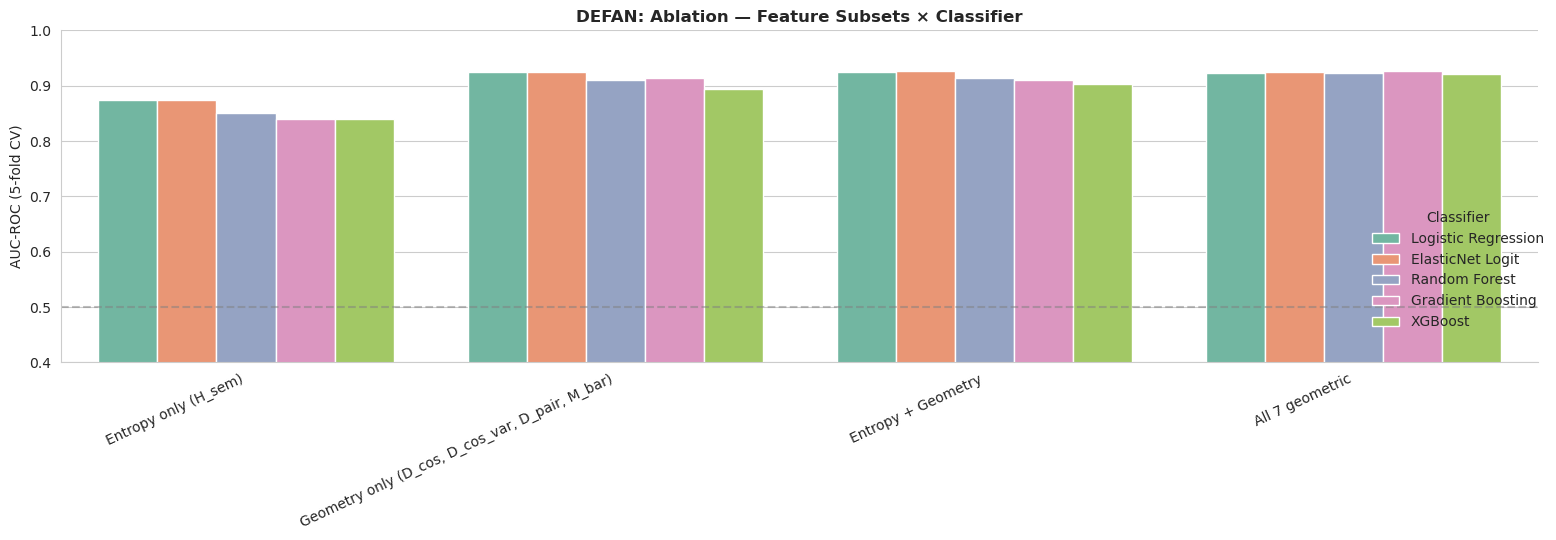

In [6]:
fig = plot_ablation_bar(df_clf_defan, dataset_name='DEFAN')
plt.savefig(os.path.join(OUTPUT_DIR, 'defan_ablation_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


### DEFAN: Ablation ROC Curves


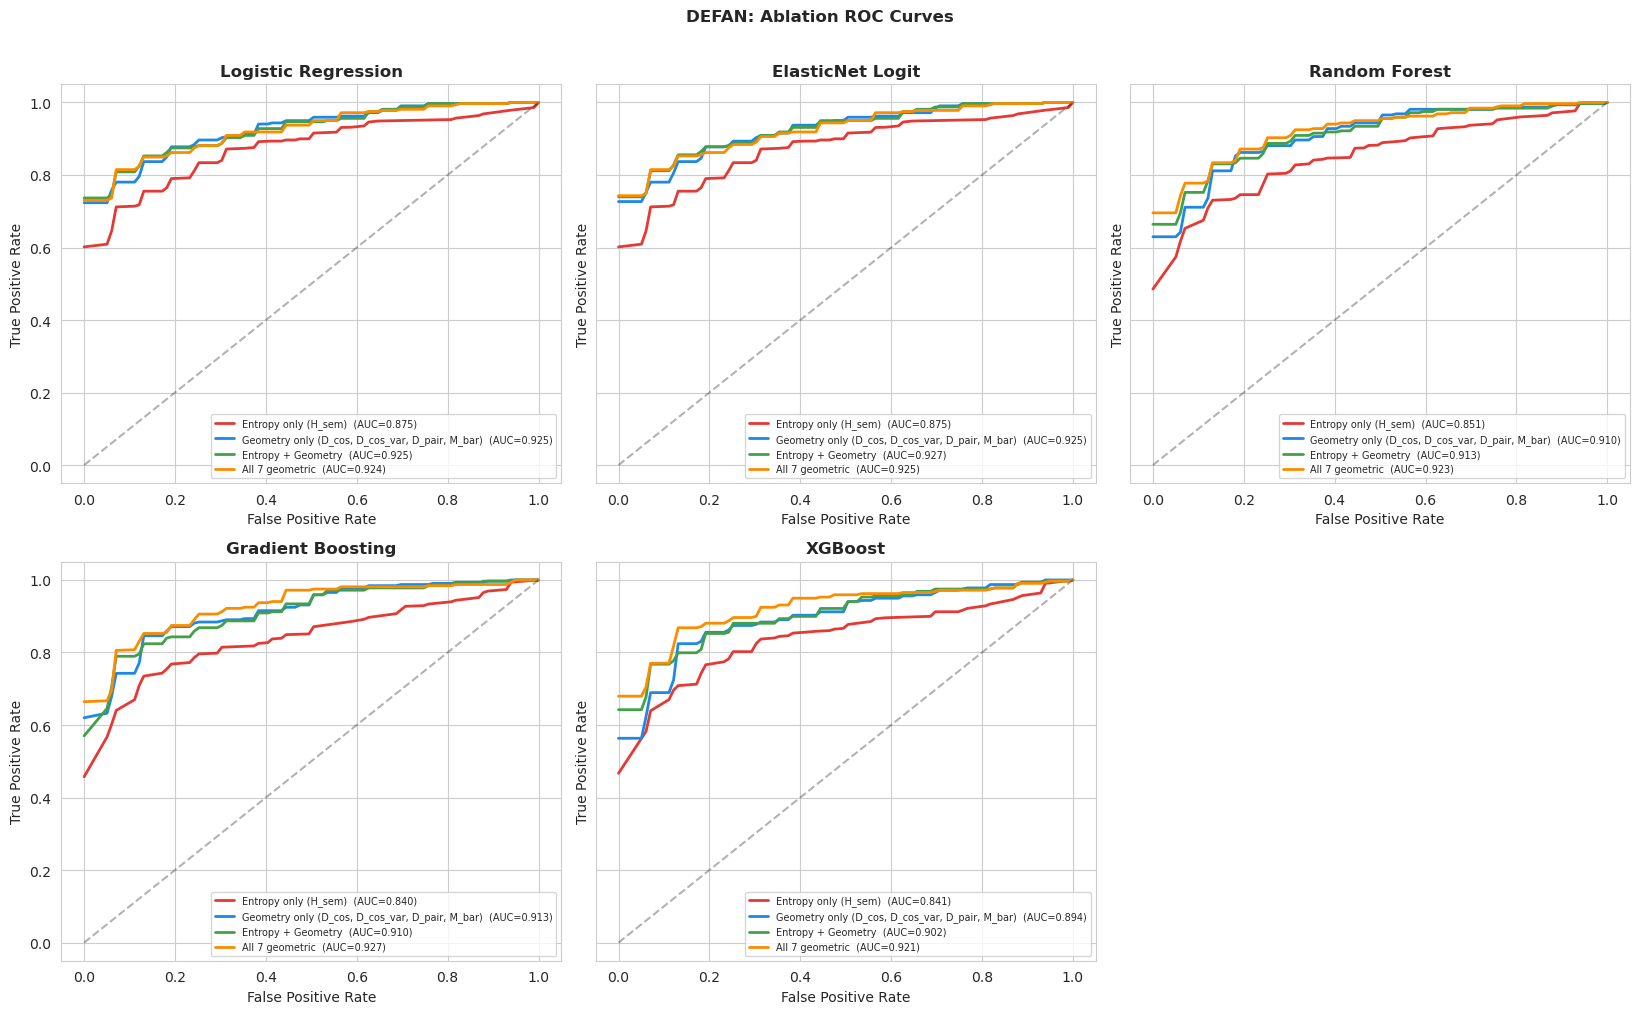

In [7]:
fig = plot_ablation_roc_curves(
    X_tr_defan, y_tr_defan,
    classifiers=build_classifiers(RANDOM_SEED),
    ablation_sets={k: ('geo', v) for k, v in ABLATION_SETS.items()},
    dataset_name='DEFAN', random_seed=RANDOM_SEED,
)
plt.savefig(os.path.join(OUTPUT_DIR, 'defan_ablation_roc.png'), dpi=150, bbox_inches='tight')
plt.show()


### DEFAN: Feature-Level ROC Curves


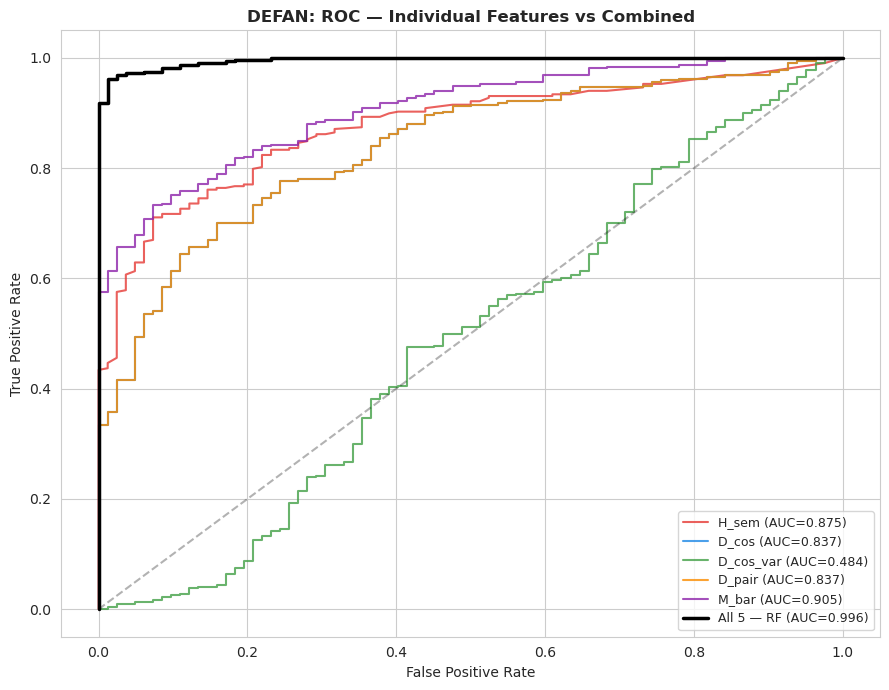

In [8]:
fig = plot_roc_curves(X_tr_defan, y_tr_defan, dataset_name='DEFAN',
                      random_seed=RANDOM_SEED)
plt.savefig(os.path.join(OUTPUT_DIR, 'defan_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


### DEFAN: ROC & Precision-Recall



=== DEFAN — Metrics ({_eval_label_defan) ===
  roc_auc                   0.8953
  average_precision         0.9740
  brier_score               0.1226
  accuracy_at_0.5           0.8200
  precision_at_0.5          0.9079
  recall_at_0.5             0.8625
  f1_at_0.5                 0.8846


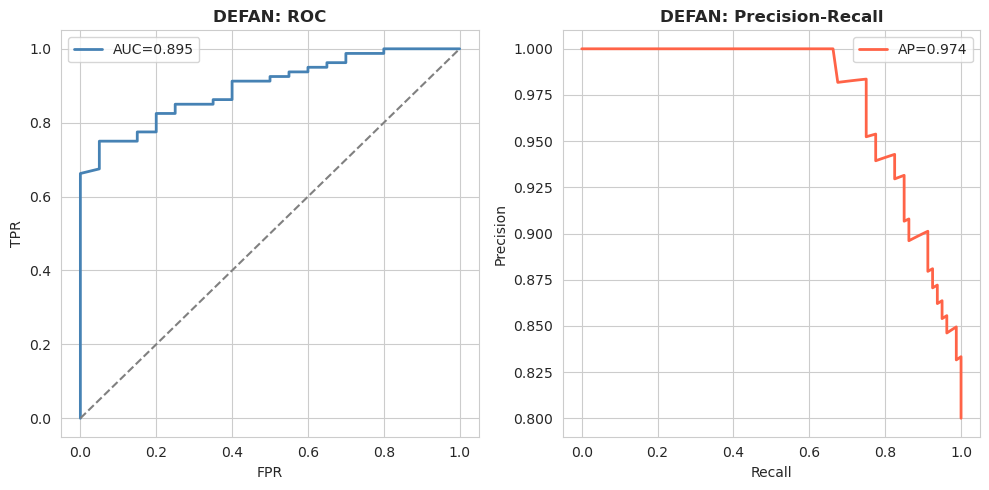

In [9]:
if USE_HOLDOUT:
    _bundle_defan = evaluate_final_model(
        best_defan, X_tr_defan, X_te_defan,
        y_tr_defan, y_te_defan,
        feat_names=GEO_FEATURES, random_seed=RANDOM_SEED,
    )
    _eval_label_defan = 'hold-out test set'
else:
    _bundle_defan = evaluate_cv_predictions(
        feat_dfs['defan'], best_defan, random_seed=RANDOM_SEED,
    )
    _eval_label_defan = 'CV out-of-fold'

print(f'\n=== DEFAN — Metrics ({{_eval_label_defan) ===')
for k, v in _bundle_defan['test_metrics'].items():
    print(f'  {k:25s} {v:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
auc_v = _bundle_defan['test_metrics']['roc_auc']
ap_v  = _bundle_defan['test_metrics']['average_precision']
axes[0].plot(_bundle_defan['roc_curve_df']['fpr'],
             _bundle_defan['roc_curve_df']['tpr'],
             color='steelblue', lw=2, label=f'AUC={auc_v:.3f}')
axes[0].plot([0,1],[0,1],'--',color='gray'); axes[0].legend()
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title(f'DEFAN: ROC', fontweight='bold')
axes[1].plot(_bundle_defan['pr_curve_df']['recall'],
             _bundle_defan['pr_curve_df']['precision'],
             color='tomato', lw=2, label=f'AP={ap_v:.3f}')
axes[1].legend(); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'DEFAN: Precision-Recall', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'defan_roc_pr.png'), dpi=150, bbox_inches='tight')
plt.show()


### DEFAN: Per-Domain Classification

> **Exploratory only.** CV within each domain sub-group. No train/test split within domains — sample counts are too small. See domain validity caveat in eda.ipynb.


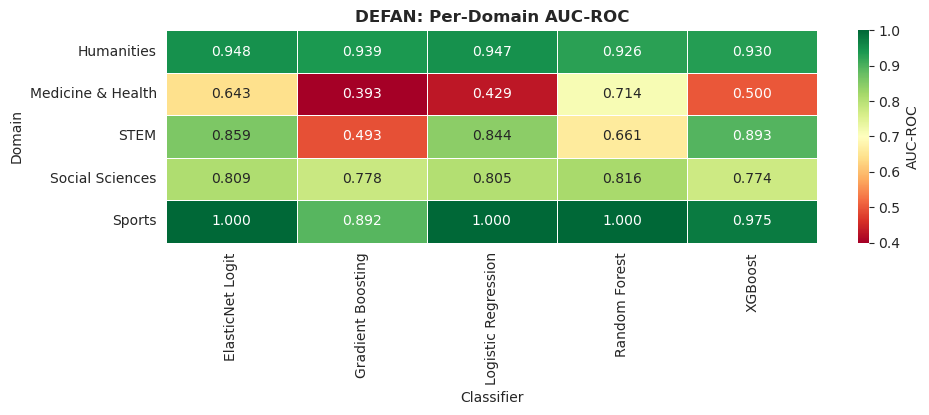

In [10]:
_ad_defan, _ex_defan = split_analysis_domains(
    feat_dfs['defan'], MIN_QUESTIONS_FOR_ANALYSIS, domain_col='domain',
)
df_dom_defan = run_per_domain_clf(
    feat_dfs['defan'], analysis_domains=_ad_defan,
    excluded_domains=_ex_defan, domain_col='domain', random_seed=RANDOM_SEED,
)
df_dom_defan.to_csv(os.path.join(OUTPUT_DIR, 'defan_per_domain_clf.csv'), index=False)
fig = plot_per_domain_clf_heatmap(df_dom_defan, dataset_name='DEFAN')
plt.savefig(os.path.join(OUTPUT_DIR, 'defan_per_domain_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


### DEFAN: SHAP


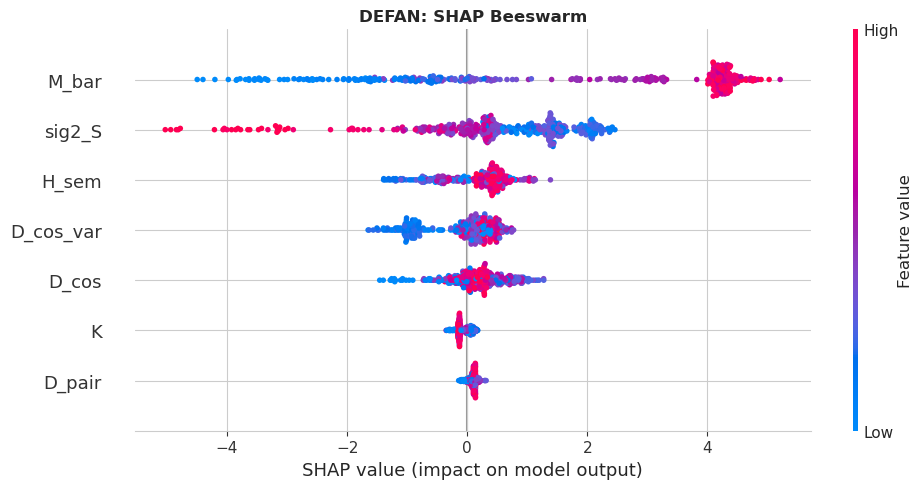

In [11]:
fig = plot_shap_beeswarm(X_tr_defan, y_tr_defan,
                         title='DEFAN: SHAP Beeswarm')
plt.savefig(os.path.join(OUTPUT_DIR, 'defan_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## HALUEVAL


### HALUEVAL: Model Selection


In [12]:
if USE_HOLDOUT:
    X_tr_halueval, X_te_halueval, y_tr_halueval, y_te_halueval, _ = make_train_test_split(
        feat_dfs['halueval'], random_seed=RANDOM_SEED,
    )
    df_cv_halueval, best_halueval = run_cv_model_selection(
        X_tr_halueval, y_tr_halueval, random_seed=RANDOM_SEED,
    )
else:
    df_cv_halueval, best_halueval = run_cv_model_selection(
        feat_dfs['halueval'], random_seed=RANDOM_SEED,
    )
    X_tr_halueval = None  # set below in ablation
    y_tr_halueval = None
display(df_cv_halueval)


Train: 400  |  Test: 100
Train hallucination rate: 7.2%
Test  hallucination rate: 7.0%
CV model selection — mode: holdout-train  |  n=400  |  hallu rate=7.2%
  Logistic Regression       | AUC=0.7523±0.0978  AP=0.2689
  ElasticNet Logit          | AUC=0.7565±0.0988  AP=0.3003
  Random Forest             | AUC=0.8274±0.0747  AP=0.4219
  Gradient Boosting         | AUC=0.8383±0.0667  AP=0.3831
  XGBoost                   | AUC=0.8191±0.0714  AP=0.3263

Best classifier: Gradient Boosting


,Classifier,CV_AUC_mean,CV_AUC_std,CV_AP_mean,CV_AP_std
3,Gradient Boosting,0.838330,0.066737,0.383098,0.103207
2,Random Forest,0.827413,0.074683,0.421897,0.112836
4,XGBoost,0.819150,0.071408,0.326324,0.076211
1,ElasticNet Logit,0.756508,0.098790,0.300255,0.125010
0,Logistic Regression,0.752335,0.097782,0.268864,0.102597


### HALUEVAL: Ablation


In [13]:
df_clf_halueval, X_tr_halueval, X_te_halueval, y_tr_halueval, y_te_halueval = run_ablation(
    feat_dfs['halueval'],
    random_seed=RANDOM_SEED,
    use_holdout=USE_HOLDOUT,
)
metric_col = 'Test_AUC' if USE_HOLDOUT else 'CV_AUC_mean'
df_clf_halueval.to_csv(os.path.join(OUTPUT_DIR, 'halueval_ablation.csv'), index=False)
display(df_clf_halueval.pivot_table(
    index='Variant', columns='Classifier', values=metric_col).round(3))


Train: 400  |  Test: 100
Train hallucination rate: 7.2%
Test  hallucination rate: 7.0%
Ablation — HOLDOUT MODE  (train=400, test=100)
  Entropy only (H_sem)                       | Logistic Regression       | CV=0.7709  Test=0.9240
  Entropy only (H_sem)                       | ElasticNet Logit          | CV=0.7709  Test=0.9240
  Entropy only (H_sem)                       | Random Forest             | CV=0.6410  Test=0.8940
  Entropy only (H_sem)                       | Gradient Boosting         | CV=0.6357  Test=0.8356
  Entropy only (H_sem)                       | XGBoost                   | CV=0.6750  Test=0.9186
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Logistic Regression       | CV=0.7551  Test=0.9508
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | ElasticNet Logit          | CV=0.7526  Test=0.9508
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Random Forest             | CV=0.8609  Test=0.9631
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Gradient Boosti

Classifier,ElasticNet Logit,Gradient Boosting,Logistic Regression,Random Forest,XGBoost
Variant,,,,,
All 7 geometric,0.957,0.967,0.955,0.982,0.963
Entropy + Geometry,0.957,0.972,0.955,0.977,0.985
Entropy only (H_sem),0.924,0.836,0.924,0.894,0.919
"Geometry only (D_cos, D_cos_var, D_pair, M_bar)",0.951,0.955,0.951,0.963,0.972


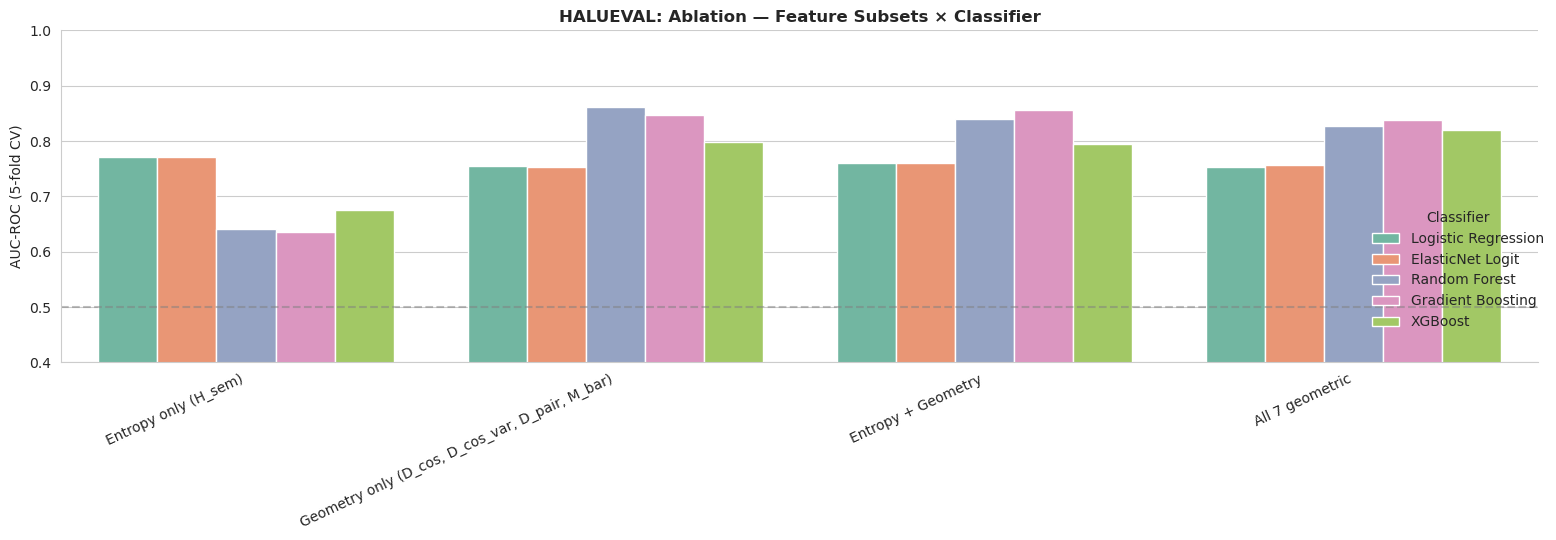

In [14]:
fig = plot_ablation_bar(df_clf_halueval, dataset_name='HALUEVAL')
plt.savefig(os.path.join(OUTPUT_DIR, 'halueval_ablation_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


### HALUEVAL: Ablation ROC Curves


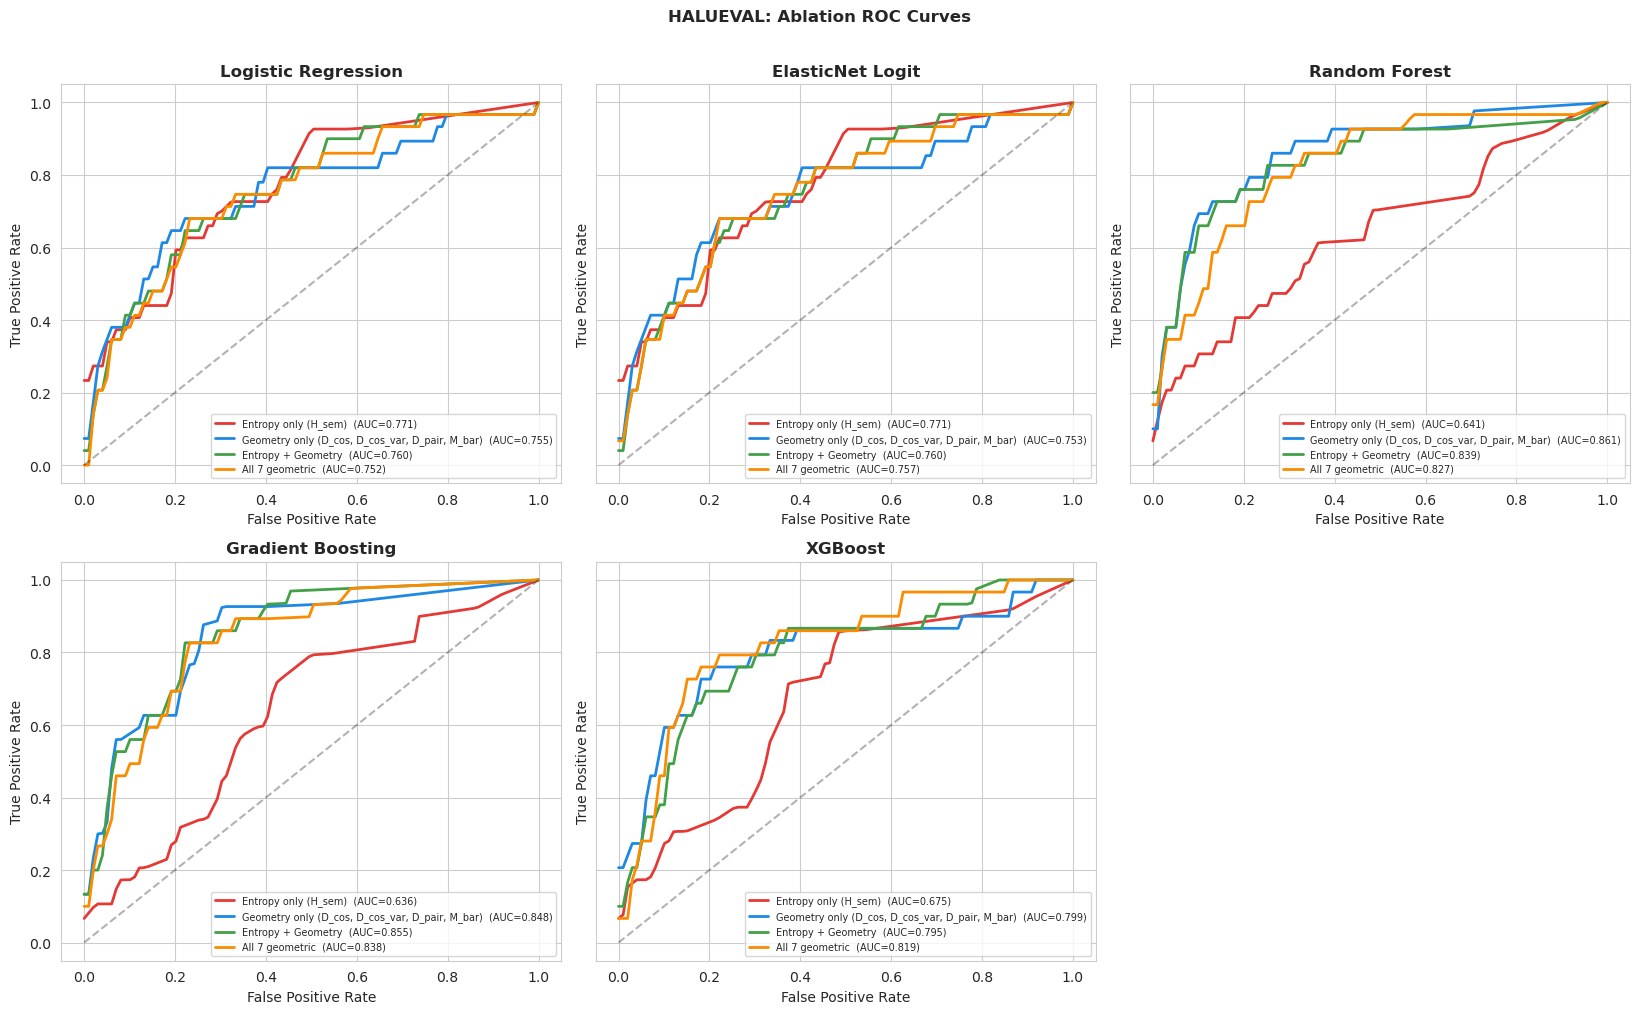

In [15]:
fig = plot_ablation_roc_curves(
    X_tr_halueval, y_tr_halueval,
    classifiers=build_classifiers(RANDOM_SEED),
    ablation_sets={k: ('geo', v) for k, v in ABLATION_SETS.items()},
    dataset_name='HALUEVAL', random_seed=RANDOM_SEED,
)
plt.savefig(os.path.join(OUTPUT_DIR, 'halueval_ablation_roc.png'), dpi=150, bbox_inches='tight')
plt.show()


### HALUEVAL: Feature-Level ROC Curves


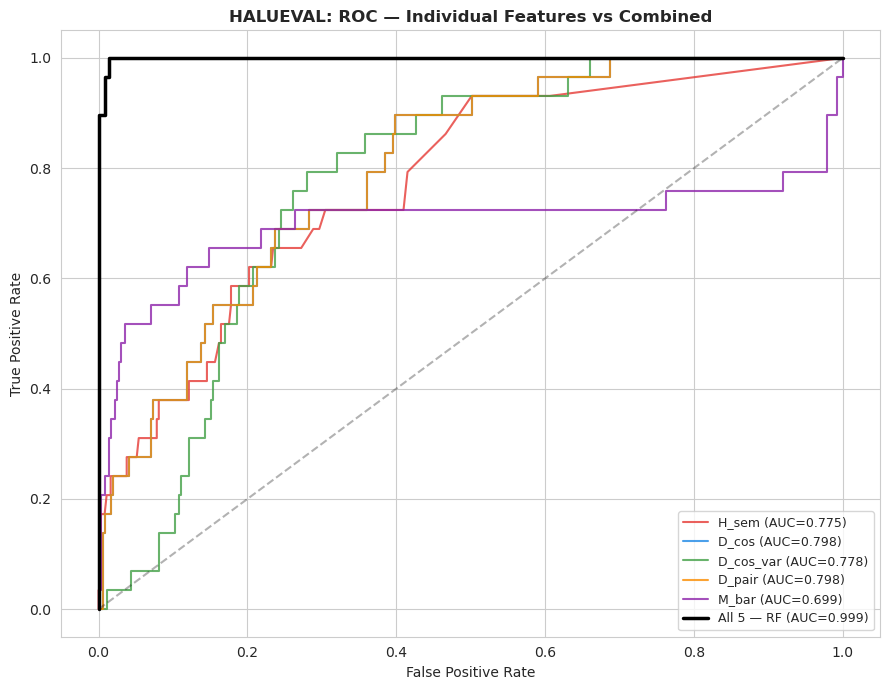

In [16]:
fig = plot_roc_curves(X_tr_halueval, y_tr_halueval, dataset_name='HALUEVAL',
                      random_seed=RANDOM_SEED)
plt.savefig(os.path.join(OUTPUT_DIR, 'halueval_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


### HALUEVAL: ROC & Precision-Recall



=== HALUEVAL — Metrics ({_eval_label_halueval) ===
  roc_auc                   0.9670
  average_precision         0.6624
  brier_score               0.0464
  accuracy_at_0.5           0.9400
  precision_at_0.5          0.6667
  recall_at_0.5             0.2857
  f1_at_0.5                 0.4000


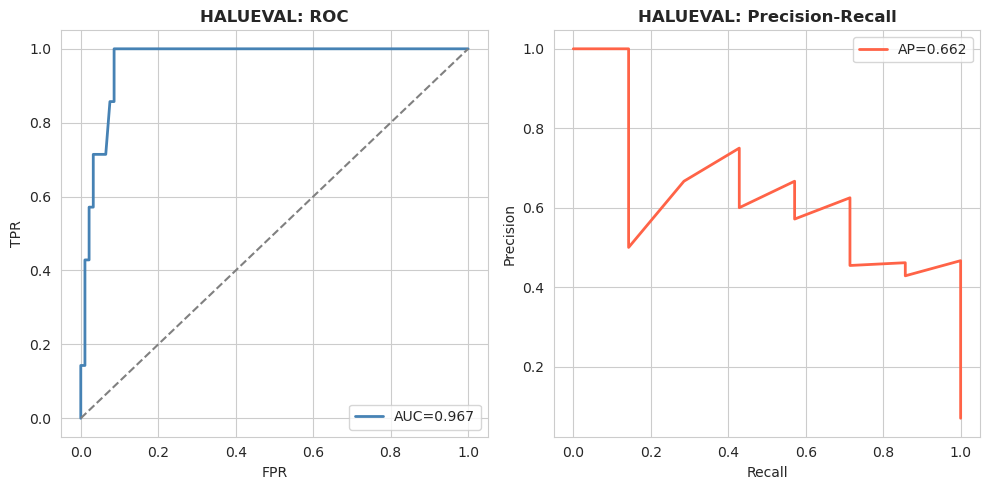

In [17]:
if USE_HOLDOUT:
    _bundle_halueval = evaluate_final_model(
        best_halueval, X_tr_halueval, X_te_halueval,
        y_tr_halueval, y_te_halueval,
        feat_names=GEO_FEATURES, random_seed=RANDOM_SEED,
    )
    _eval_label_halueval = 'hold-out test set'
else:
    _bundle_halueval = evaluate_cv_predictions(
        feat_dfs['halueval'], best_halueval, random_seed=RANDOM_SEED,
    )
    _eval_label_halueval = 'CV out-of-fold'

print(f'\n=== HALUEVAL — Metrics ({{_eval_label_halueval) ===')
for k, v in _bundle_halueval['test_metrics'].items():
    print(f'  {k:25s} {v:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
auc_v = _bundle_halueval['test_metrics']['roc_auc']
ap_v  = _bundle_halueval['test_metrics']['average_precision']
axes[0].plot(_bundle_halueval['roc_curve_df']['fpr'],
             _bundle_halueval['roc_curve_df']['tpr'],
             color='steelblue', lw=2, label=f'AUC={auc_v:.3f}')
axes[0].plot([0,1],[0,1],'--',color='gray'); axes[0].legend()
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title(f'HALUEVAL: ROC', fontweight='bold')
axes[1].plot(_bundle_halueval['pr_curve_df']['recall'],
             _bundle_halueval['pr_curve_df']['precision'],
             color='tomato', lw=2, label=f'AP={ap_v:.3f}')
axes[1].legend(); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'HALUEVAL: Precision-Recall', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'halueval_roc_pr.png'), dpi=150, bbox_inches='tight')
plt.show()


### HALUEVAL: Per-Domain Classification

> **Exploratory only.** CV within each domain sub-group. No train/test split within domains — sample counts are too small. See domain validity caveat in eda.ipynb.


Excluded from per-domain classification: ['Medicine & Health']


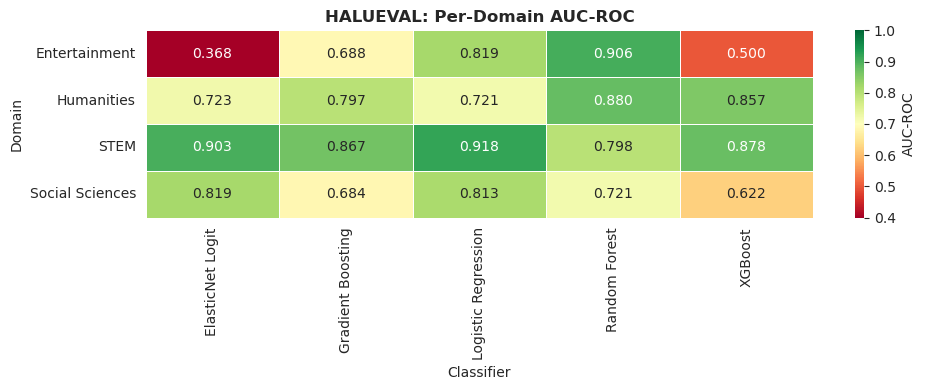

In [18]:
_ad_halueval, _ex_halueval = split_analysis_domains(
    feat_dfs['halueval'], MIN_QUESTIONS_FOR_ANALYSIS, domain_col='domain_canonical',
)
df_dom_halueval = run_per_domain_clf(
    feat_dfs['halueval'], analysis_domains=_ad_halueval,
    excluded_domains=_ex_halueval, domain_col='domain_canonical', random_seed=RANDOM_SEED,
)
df_dom_halueval.to_csv(os.path.join(OUTPUT_DIR, 'halueval_per_domain_clf.csv'), index=False)
fig = plot_per_domain_clf_heatmap(df_dom_halueval, dataset_name='HALUEVAL')
plt.savefig(os.path.join(OUTPUT_DIR, 'halueval_per_domain_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


### HALUEVAL: SHAP


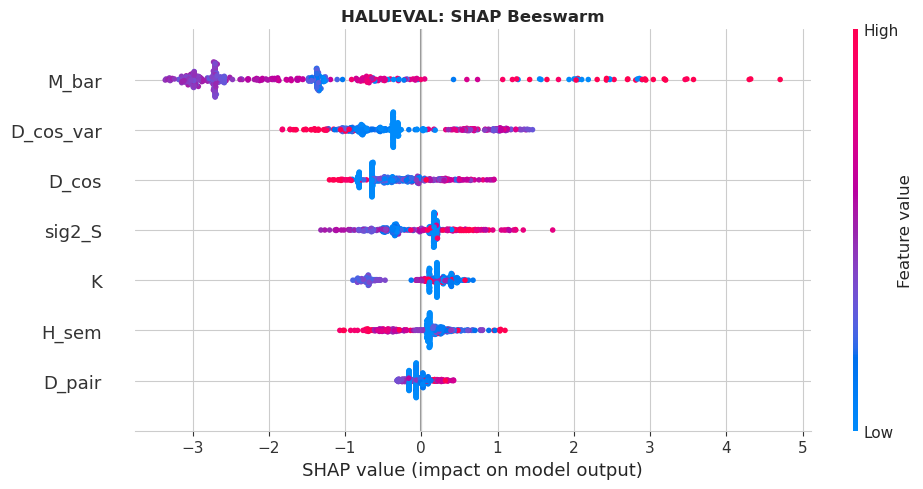

In [19]:
fig = plot_shap_beeswarm(X_tr_halueval, y_tr_halueval,
                         title='HALUEVAL: SHAP Beeswarm')
plt.savefig(os.path.join(OUTPUT_DIR, 'halueval_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## MMLU


### MMLU: Model Selection


In [20]:
if USE_HOLDOUT:
    X_tr_mmlu, X_te_mmlu, y_tr_mmlu, y_te_mmlu, _ = make_train_test_split(
        feat_dfs['mmlu'], random_seed=RANDOM_SEED,
    )
    df_cv_mmlu, best_mmlu = run_cv_model_selection(
        X_tr_mmlu, y_tr_mmlu, random_seed=RANDOM_SEED,
    )
else:
    df_cv_mmlu, best_mmlu = run_cv_model_selection(
        feat_dfs['mmlu'], random_seed=RANDOM_SEED,
    )
    X_tr_mmlu = None  # set below in ablation
    y_tr_mmlu = None
display(df_cv_mmlu)


Train: 400  |  Test: 100
Train hallucination rate: 78.5%
Test  hallucination rate: 78.0%
CV model selection — mode: holdout-train  |  n=400  |  hallu rate=78.5%
  Logistic Regression       | AUC=0.9473±0.0213  AP=0.9852
  ElasticNet Logit          | AUC=0.9469±0.0218  AP=0.9851
  Random Forest             | AUC=0.9153±0.0385  AP=0.9737
  Gradient Boosting         | AUC=0.9292±0.0306  AP=0.9807
  XGBoost                   | AUC=0.9092±0.0342  AP=0.9731

Best classifier: Logistic Regression


,Classifier,CV_AUC_mean,CV_AUC_std,CV_AP_mean,CV_AP_std
0,Logistic Regression,0.947262,0.021304,0.985197,0.006423
1,ElasticNet Logit,0.946889,0.021754,0.985072,0.006598
3,Gradient Boosting,0.929210,0.030626,0.980746,0.008856
2,Random Forest,0.915272,0.038464,0.973652,0.013880
4,XGBoost,0.909208,0.034176,0.973069,0.011355


### MMLU: Ablation


In [21]:
df_clf_mmlu, X_tr_mmlu, X_te_mmlu, y_tr_mmlu, y_te_mmlu = run_ablation(
    feat_dfs['mmlu'],
    random_seed=RANDOM_SEED,
    use_holdout=USE_HOLDOUT,
)
metric_col = 'Test_AUC' if USE_HOLDOUT else 'CV_AUC_mean'
df_clf_mmlu.to_csv(os.path.join(OUTPUT_DIR, 'mmlu_ablation.csv'), index=False)
display(df_clf_mmlu.pivot_table(
    index='Variant', columns='Classifier', values=metric_col).round(3))


Train: 400  |  Test: 100
Train hallucination rate: 78.5%
Test  hallucination rate: 78.0%
Ablation — HOLDOUT MODE  (train=400, test=100)
  Entropy only (H_sem)                       | Logistic Regression       | CV=0.7146  Test=0.6492
  Entropy only (H_sem)                       | ElasticNet Logit          | CV=0.7146  Test=0.6492
  Entropy only (H_sem)                       | Random Forest             | CV=0.6114  Test=0.6544
  Entropy only (H_sem)                       | Gradient Boosting         | CV=0.5539  Test=0.6579
  Entropy only (H_sem)                       | XGBoost                   | CV=0.5808  Test=0.6422
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Logistic Regression       | CV=0.9487  Test=0.9545
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | ElasticNet Logit          | CV=0.9484  Test=0.9528
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Random Forest             | CV=0.9402  Test=0.9283
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Gradient Boos

Classifier,ElasticNet Logit,Gradient Boosting,Logistic Regression,Random Forest,XGBoost
Variant,,,,,
All 7 geometric,0.953,0.929,0.955,0.903,0.918
Entropy + Geometry,0.953,0.932,0.953,0.931,0.931
Entropy only (H_sem),0.649,0.658,0.649,0.654,0.642
"Geometry only (D_cos, D_cos_var, D_pair, M_bar)",0.953,0.936,0.955,0.928,0.911


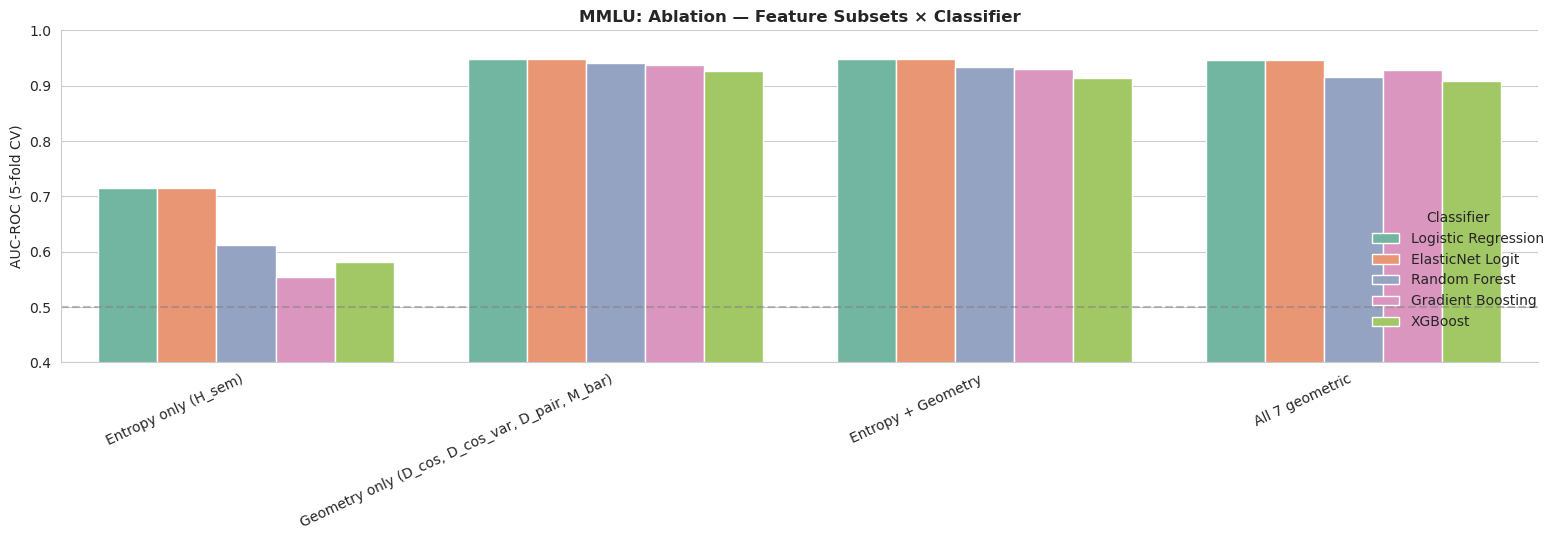

In [22]:
fig = plot_ablation_bar(df_clf_mmlu, dataset_name='MMLU')
plt.savefig(os.path.join(OUTPUT_DIR, 'mmlu_ablation_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


### MMLU: Ablation ROC Curves


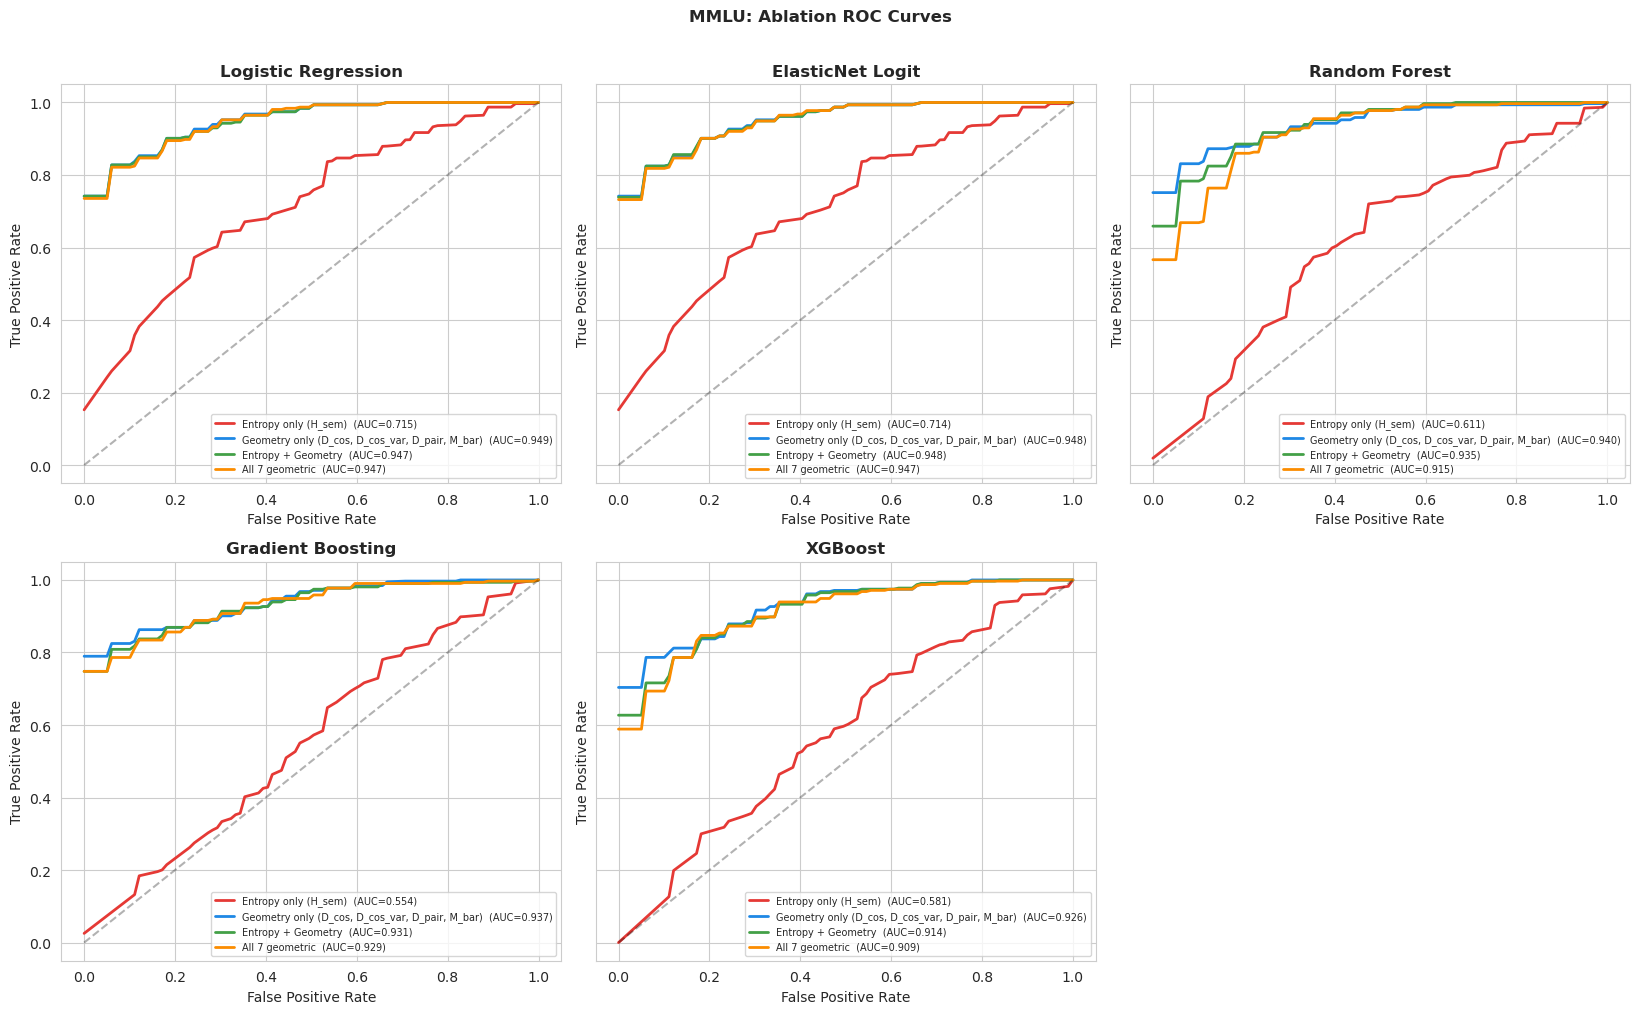

In [23]:
fig = plot_ablation_roc_curves(
    X_tr_mmlu, y_tr_mmlu,
    classifiers=build_classifiers(RANDOM_SEED),
    ablation_sets={k: ('geo', v) for k, v in ABLATION_SETS.items()},
    dataset_name='MMLU', random_seed=RANDOM_SEED,
)
plt.savefig(os.path.join(OUTPUT_DIR, 'mmlu_ablation_roc.png'), dpi=150, bbox_inches='tight')
plt.show()


### MMLU: Feature-Level ROC Curves


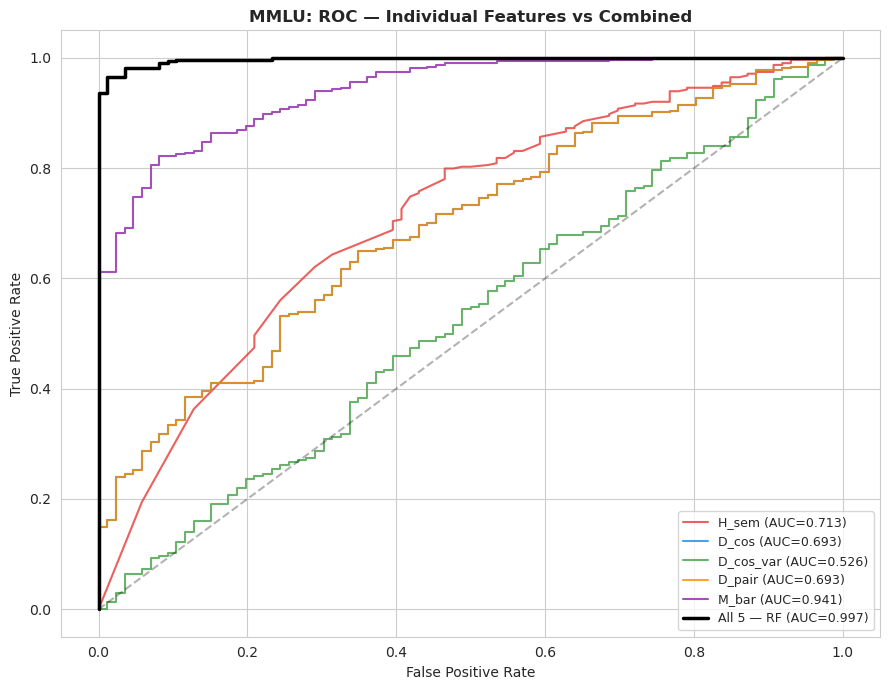

In [24]:
fig = plot_roc_curves(X_tr_mmlu, y_tr_mmlu, dataset_name='MMLU',
                      random_seed=RANDOM_SEED)
plt.savefig(os.path.join(OUTPUT_DIR, 'mmlu_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


### MMLU: ROC & Precision-Recall



=== MMLU — Metrics ({_eval_label_mmlu) ===
  roc_auc                   0.9545
  average_precision         0.9879
  brier_score               0.0767
  accuracy_at_0.5           0.8900
  precision_at_0.5          0.8941
  recall_at_0.5             0.9744
  f1_at_0.5                 0.9325


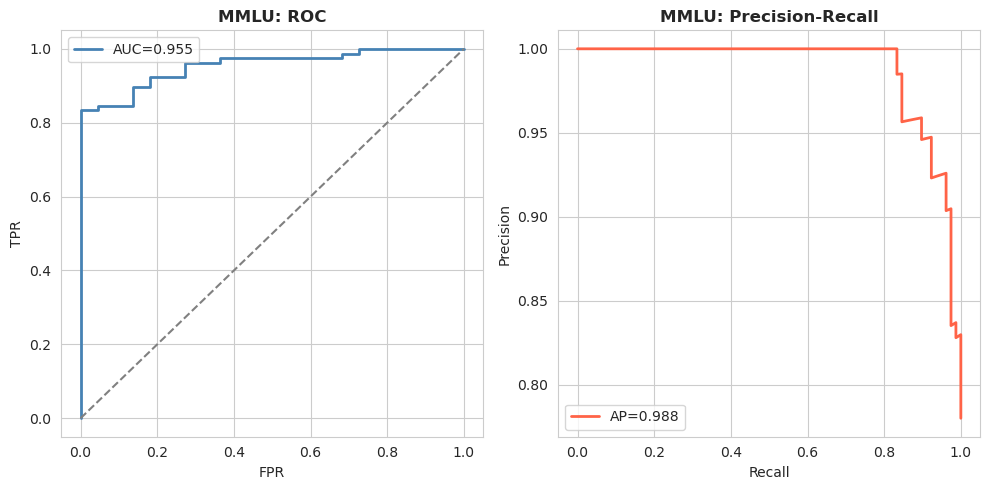

In [25]:
if USE_HOLDOUT:
    _bundle_mmlu = evaluate_final_model(
        best_mmlu, X_tr_mmlu, X_te_mmlu,
        y_tr_mmlu, y_te_mmlu,
        feat_names=GEO_FEATURES, random_seed=RANDOM_SEED,
    )
    _eval_label_mmlu = 'hold-out test set'
else:
    _bundle_mmlu = evaluate_cv_predictions(
        feat_dfs['mmlu'], best_mmlu, random_seed=RANDOM_SEED,
    )
    _eval_label_mmlu = 'CV out-of-fold'

print(f'\n=== MMLU — Metrics ({{_eval_label_mmlu) ===')
for k, v in _bundle_mmlu['test_metrics'].items():
    print(f'  {k:25s} {v:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
auc_v = _bundle_mmlu['test_metrics']['roc_auc']
ap_v  = _bundle_mmlu['test_metrics']['average_precision']
axes[0].plot(_bundle_mmlu['roc_curve_df']['fpr'],
             _bundle_mmlu['roc_curve_df']['tpr'],
             color='steelblue', lw=2, label=f'AUC={auc_v:.3f}')
axes[0].plot([0,1],[0,1],'--',color='gray'); axes[0].legend()
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title(f'MMLU: ROC', fontweight='bold')
axes[1].plot(_bundle_mmlu['pr_curve_df']['recall'],
             _bundle_mmlu['pr_curve_df']['precision'],
             color='tomato', lw=2, label=f'AP={ap_v:.3f}')
axes[1].legend(); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'MMLU: Precision-Recall', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mmlu_roc_pr.png'), dpi=150, bbox_inches='tight')
plt.show()


### MMLU: Per-Domain Classification

> **Exploratory only.** CV within each domain sub-group. No train/test split within domains — sample counts are too small. See domain validity caveat in eda.ipynb.


Excluded from per-domain classification: ['Entertainment', 'Food & Nutrition', 'Sports']


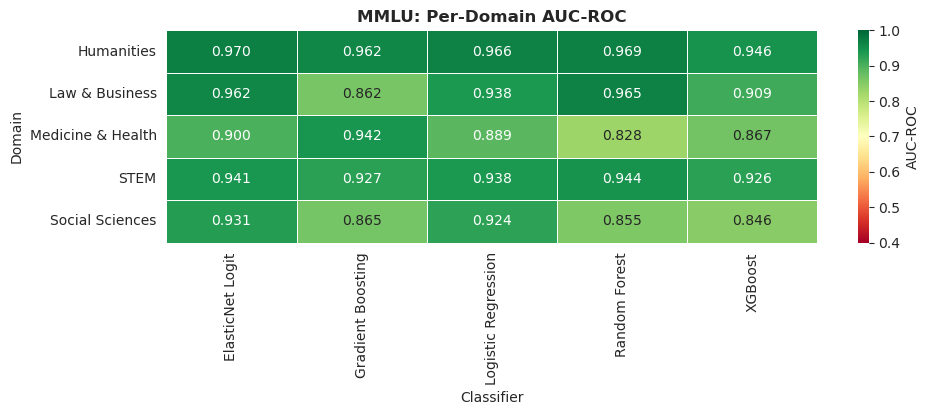

In [26]:
_ad_mmlu, _ex_mmlu = split_analysis_domains(
    feat_dfs['mmlu'], MIN_QUESTIONS_FOR_ANALYSIS, domain_col='domain_canonical',
)
df_dom_mmlu = run_per_domain_clf(
    feat_dfs['mmlu'], analysis_domains=_ad_mmlu,
    excluded_domains=_ex_mmlu, domain_col='domain_canonical', random_seed=RANDOM_SEED,
)
df_dom_mmlu.to_csv(os.path.join(OUTPUT_DIR, 'mmlu_per_domain_clf.csv'), index=False)
fig = plot_per_domain_clf_heatmap(df_dom_mmlu, dataset_name='MMLU')
plt.savefig(os.path.join(OUTPUT_DIR, 'mmlu_per_domain_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


### MMLU: SHAP


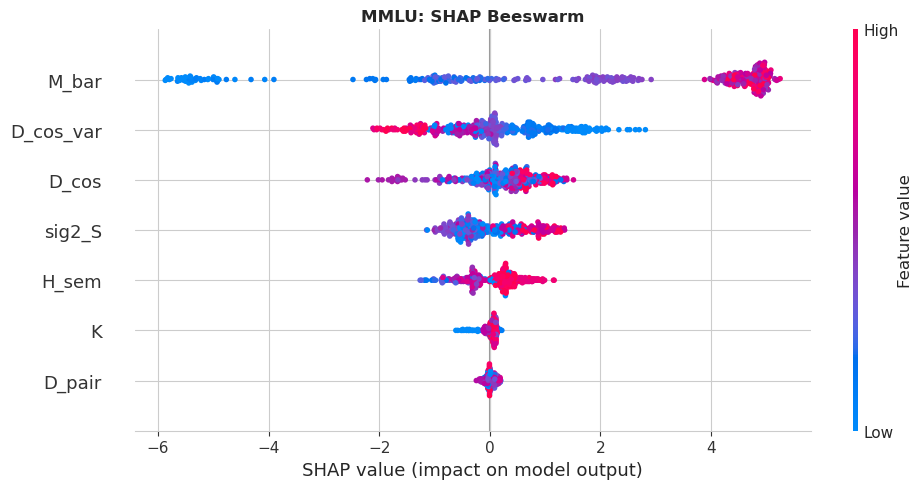

In [27]:
fig = plot_shap_beeswarm(X_tr_mmlu, y_tr_mmlu,
                         title='MMLU: SHAP Beeswarm')
plt.savefig(os.path.join(OUTPUT_DIR, 'mmlu_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## TRIVIAQA


### TRIVIAQA: Model Selection


In [28]:
if USE_HOLDOUT:
    X_tr_triviaqa, X_te_triviaqa, y_tr_triviaqa, y_te_triviaqa, _ = make_train_test_split(
        feat_dfs['triviaqa'], random_seed=RANDOM_SEED,
    )
    df_cv_triviaqa, best_triviaqa = run_cv_model_selection(
        X_tr_triviaqa, y_tr_triviaqa, random_seed=RANDOM_SEED,
    )
else:
    df_cv_triviaqa, best_triviaqa = run_cv_model_selection(
        feat_dfs['triviaqa'], random_seed=RANDOM_SEED,
    )
    X_tr_triviaqa = None  # set below in ablation
    y_tr_triviaqa = None
display(df_cv_triviaqa)


Train: 400  |  Test: 100
Train hallucination rate: 41.5%
Test  hallucination rate: 42.0%
CV model selection — mode: holdout-train  |  n=400  |  hallu rate=41.5%
  Logistic Regression       | AUC=0.9746±0.0123  AP=0.9712
  ElasticNet Logit          | AUC=0.9746±0.0125  AP=0.9715
  Random Forest             | AUC=0.9661±0.0164  AP=0.9596
  Gradient Boosting         | AUC=0.9659±0.0161  AP=0.9565
  XGBoost                   | AUC=0.9655±0.0224  AP=0.9613

Best classifier: ElasticNet Logit


,Classifier,CV_AUC_mean,CV_AUC_std,CV_AP_mean,CV_AP_std
1,ElasticNet Logit,0.974650,0.012480,0.971529,0.019287
0,Logistic Regression,0.974646,0.012275,0.971211,0.020064
2,Random Forest,0.966072,0.016383,0.959578,0.021572
3,Gradient Boosting,0.965913,0.016113,0.956548,0.027301
4,XGBoost,0.965459,0.022366,0.961338,0.022747


### TRIVIAQA: Ablation


In [29]:
df_clf_triviaqa, X_tr_triviaqa, X_te_triviaqa, y_tr_triviaqa, y_te_triviaqa = run_ablation(
    feat_dfs['triviaqa'],
    random_seed=RANDOM_SEED,
    use_holdout=USE_HOLDOUT,
)
metric_col = 'Test_AUC' if USE_HOLDOUT else 'CV_AUC_mean'
df_clf_triviaqa.to_csv(os.path.join(OUTPUT_DIR, 'triviaqa_ablation.csv'), index=False)
display(df_clf_triviaqa.pivot_table(
    index='Variant', columns='Classifier', values=metric_col).round(3))


Train: 400  |  Test: 100
Train hallucination rate: 41.5%
Test  hallucination rate: 42.0%
Ablation — HOLDOUT MODE  (train=400, test=100)
  Entropy only (H_sem)                       | Logistic Regression       | CV=0.9058  Test=0.9306
  Entropy only (H_sem)                       | ElasticNet Logit          | CV=0.9058  Test=0.9306
  Entropy only (H_sem)                       | Random Forest             | CV=0.8797  Test=0.9070
  Entropy only (H_sem)                       | Gradient Boosting         | CV=0.8868  Test=0.9025
  Entropy only (H_sem)                       | XGBoost                   | CV=0.8825  Test=0.9109
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Logistic Regression       | CV=0.9752  Test=0.9680
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | ElasticNet Logit          | CV=0.9748  Test=0.9692
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Random Forest             | CV=0.9636  Test=0.9803
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Gradient Boos

Classifier,ElasticNet Logit,Gradient Boosting,Logistic Regression,Random Forest,XGBoost
Variant,,,,,
All 7 geometric,0.970,0.966,0.970,0.979,0.978
Entropy + Geometry,0.969,0.967,0.968,0.981,0.972
Entropy only (H_sem),0.931,0.903,0.931,0.907,0.911
"Geometry only (D_cos, D_cos_var, D_pair, M_bar)",0.969,0.965,0.968,0.980,0.972


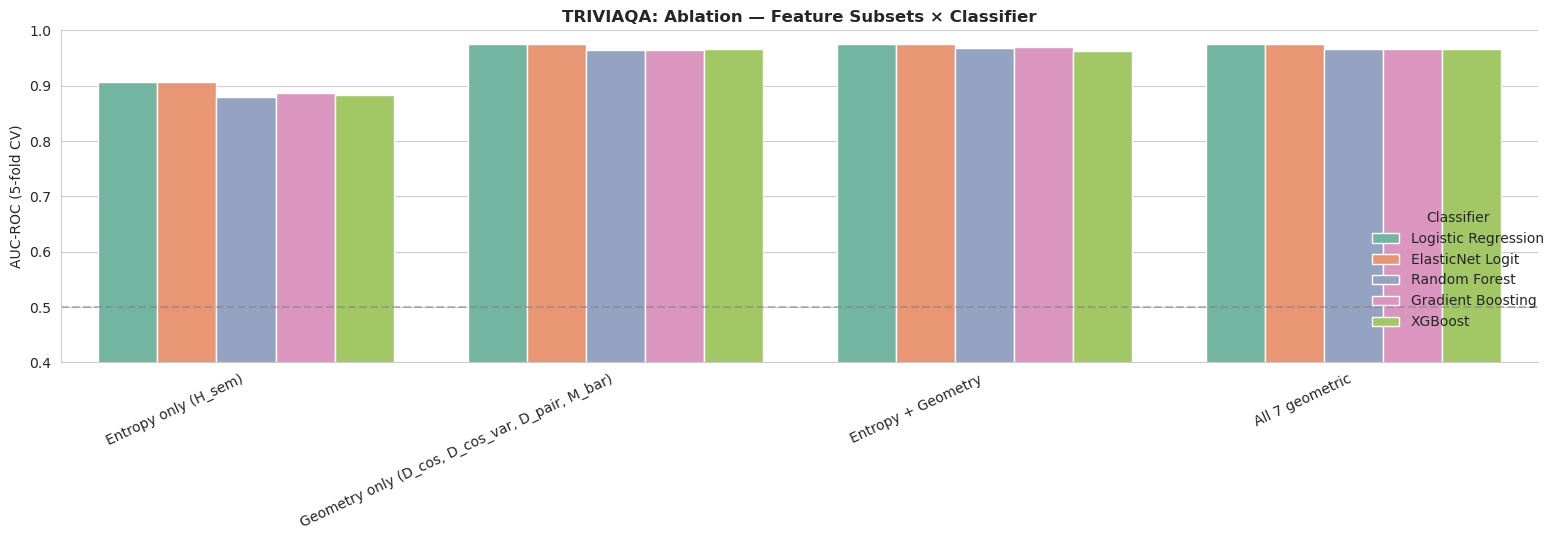

In [30]:
fig = plot_ablation_bar(df_clf_triviaqa, dataset_name='TRIVIAQA')
plt.savefig(os.path.join(OUTPUT_DIR, 'triviaqa_ablation_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRIVIAQA: Ablation ROC Curves


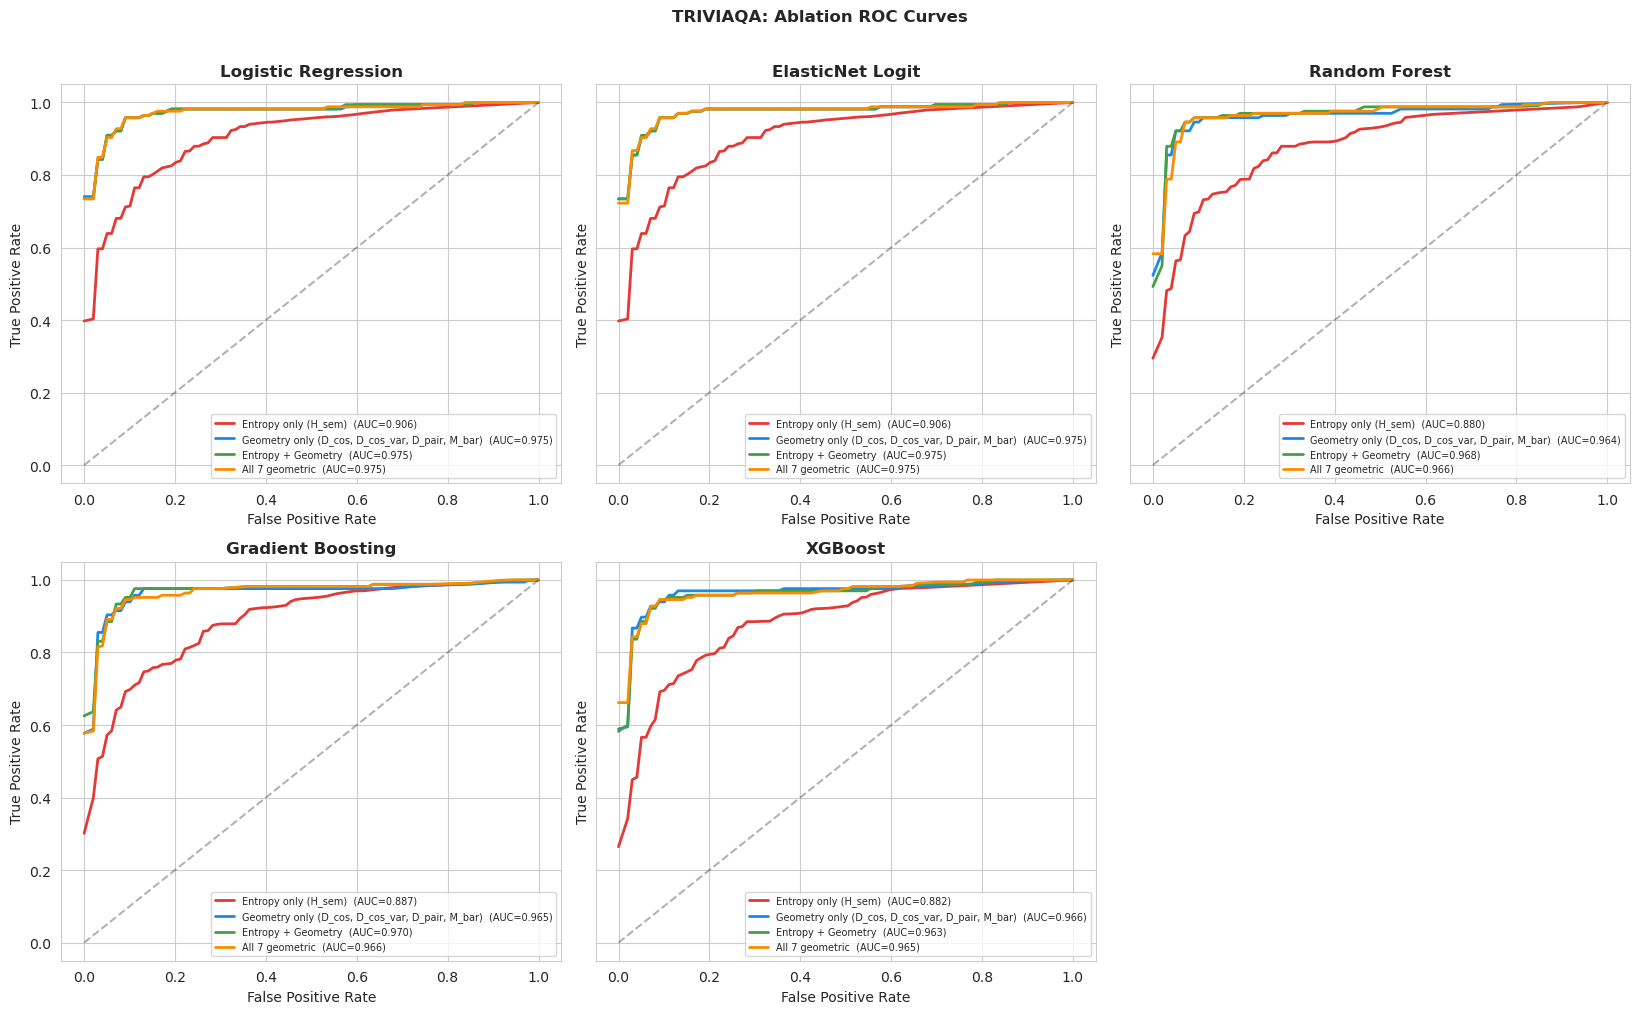

In [31]:
fig = plot_ablation_roc_curves(
    X_tr_triviaqa, y_tr_triviaqa,
    classifiers=build_classifiers(RANDOM_SEED),
    ablation_sets={k: ('geo', v) for k, v in ABLATION_SETS.items()},
    dataset_name='TRIVIAQA', random_seed=RANDOM_SEED,
)
plt.savefig(os.path.join(OUTPUT_DIR, 'triviaqa_ablation_roc.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRIVIAQA: Feature-Level ROC Curves


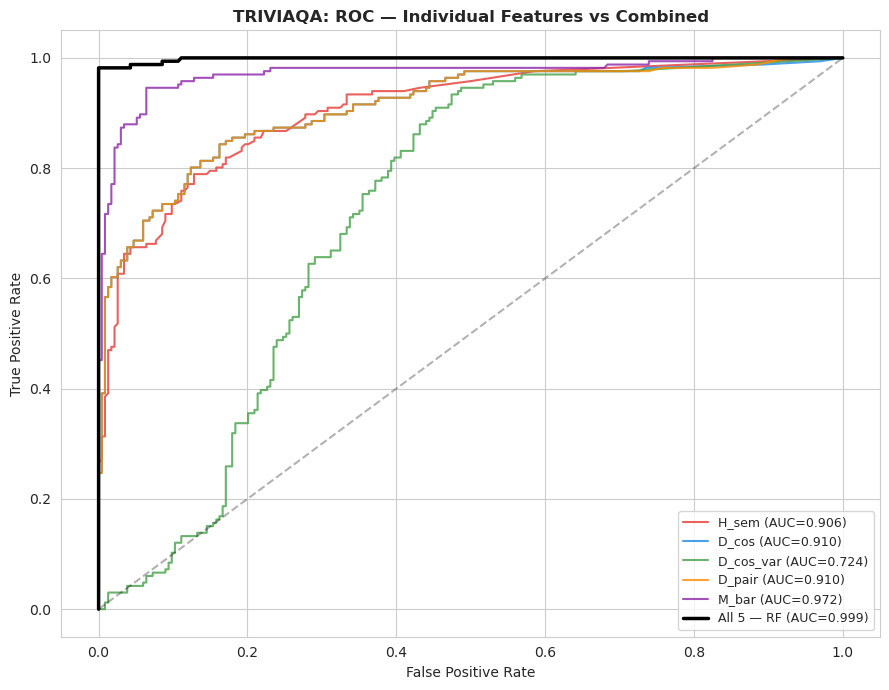

In [32]:
fig = plot_roc_curves(X_tr_triviaqa, y_tr_triviaqa, dataset_name='TRIVIAQA',
                      random_seed=RANDOM_SEED)
plt.savefig(os.path.join(OUTPUT_DIR, 'triviaqa_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRIVIAQA: ROC & Precision-Recall



=== TRIVIAQA — Metrics ({_eval_label_triviaqa) ===
  roc_auc                   0.9704
  average_precision         0.9430
  brier_score               0.0487
  accuracy_at_0.5           0.9500
  precision_at_0.5          0.8936
  recall_at_0.5             1.0000
  f1_at_0.5                 0.9438


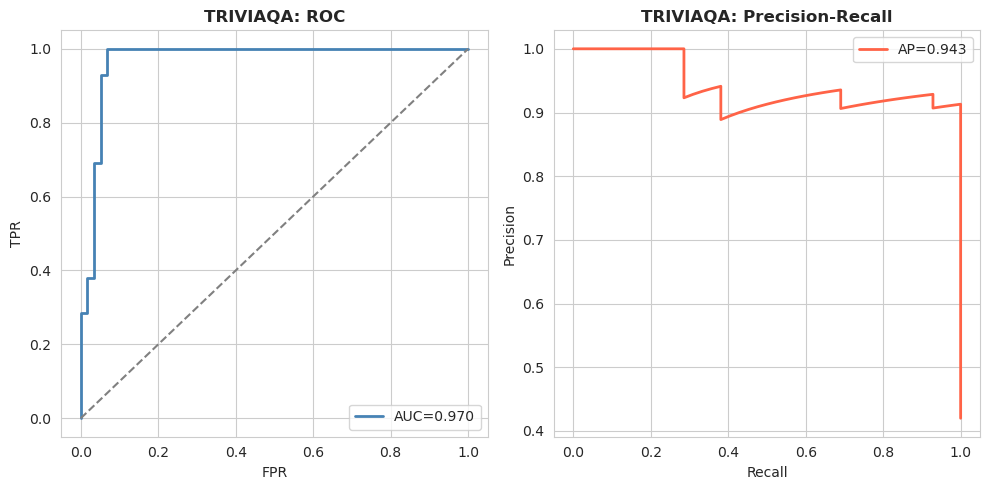

In [33]:
if USE_HOLDOUT:
    _bundle_triviaqa = evaluate_final_model(
        best_triviaqa, X_tr_triviaqa, X_te_triviaqa,
        y_tr_triviaqa, y_te_triviaqa,
        feat_names=GEO_FEATURES, random_seed=RANDOM_SEED,
    )
    _eval_label_triviaqa = 'hold-out test set'
else:
    _bundle_triviaqa = evaluate_cv_predictions(
        feat_dfs['triviaqa'], best_triviaqa, random_seed=RANDOM_SEED,
    )
    _eval_label_triviaqa = 'CV out-of-fold'

print(f'\n=== TRIVIAQA — Metrics ({{_eval_label_triviaqa) ===')
for k, v in _bundle_triviaqa['test_metrics'].items():
    print(f'  {k:25s} {v:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
auc_v = _bundle_triviaqa['test_metrics']['roc_auc']
ap_v  = _bundle_triviaqa['test_metrics']['average_precision']
axes[0].plot(_bundle_triviaqa['roc_curve_df']['fpr'],
             _bundle_triviaqa['roc_curve_df']['tpr'],
             color='steelblue', lw=2, label=f'AUC={auc_v:.3f}')
axes[0].plot([0,1],[0,1],'--',color='gray'); axes[0].legend()
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title(f'TRIVIAQA: ROC', fontweight='bold')
axes[1].plot(_bundle_triviaqa['pr_curve_df']['recall'],
             _bundle_triviaqa['pr_curve_df']['precision'],
             color='tomato', lw=2, label=f'AP={ap_v:.3f}')
axes[1].legend(); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'TRIVIAQA: Precision-Recall', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'triviaqa_roc_pr.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRIVIAQA: Per-Domain Classification

> **Exploratory only.** CV within each domain sub-group. No train/test split within domains — sample counts are too small. See domain validity caveat in eda.ipynb.


Excluded from per-domain classification: ['Geography', 'History', 'Language', 'Law & Business', 'Literature', 'Other', 'Religion & Philosophy', 'Science']


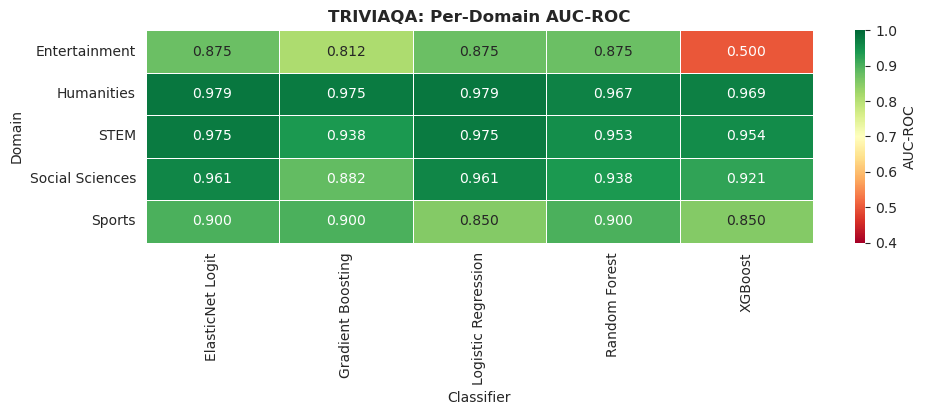

In [34]:
_ad_triviaqa, _ex_triviaqa = split_analysis_domains(
    feat_dfs['triviaqa'], MIN_QUESTIONS_FOR_ANALYSIS, domain_col='domain_canonical',
)
df_dom_triviaqa = run_per_domain_clf(
    feat_dfs['triviaqa'], analysis_domains=_ad_triviaqa,
    excluded_domains=_ex_triviaqa, domain_col='domain_canonical', random_seed=RANDOM_SEED,
)
df_dom_triviaqa.to_csv(os.path.join(OUTPUT_DIR, 'triviaqa_per_domain_clf.csv'), index=False)
fig = plot_per_domain_clf_heatmap(df_dom_triviaqa, dataset_name='TRIVIAQA')
plt.savefig(os.path.join(OUTPUT_DIR, 'triviaqa_per_domain_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRIVIAQA: SHAP


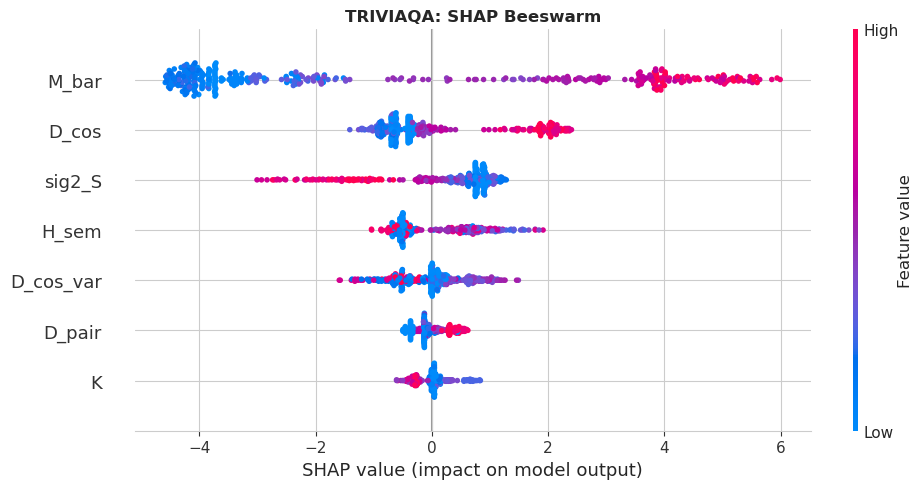

In [35]:
fig = plot_shap_beeswarm(X_tr_triviaqa, y_tr_triviaqa,
                         title='TRIVIAQA: SHAP Beeswarm')
plt.savefig(os.path.join(OUTPUT_DIR, 'triviaqa_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## TRUTHFULQA


### TRUTHFULQA: Model Selection


In [36]:
if USE_HOLDOUT:
    X_tr_truthfulqa, X_te_truthfulqa, y_tr_truthfulqa, y_te_truthfulqa, _ = make_train_test_split(
        feat_dfs['truthfulqa'], random_seed=RANDOM_SEED,
    )
    df_cv_truthfulqa, best_truthfulqa = run_cv_model_selection(
        X_tr_truthfulqa, y_tr_truthfulqa, random_seed=RANDOM_SEED,
    )
else:
    df_cv_truthfulqa, best_truthfulqa = run_cv_model_selection(
        feat_dfs['truthfulqa'], random_seed=RANDOM_SEED,
    )
    X_tr_truthfulqa = None  # set below in ablation
    y_tr_truthfulqa = None
display(df_cv_truthfulqa)


Train: 400  |  Test: 100
Train hallucination rate: 72.0%
Test  hallucination rate: 72.0%
CV model selection — mode: holdout-train  |  n=400  |  hallu rate=72.0%
  Logistic Regression       | AUC=0.9224±0.0267  AP=0.9746
  ElasticNet Logit          | AUC=0.9213±0.0257  AP=0.9743
  Random Forest             | AUC=0.9098±0.0176  AP=0.9694
  Gradient Boosting         | AUC=0.9158±0.0121  AP=0.9692
  XGBoost                   | AUC=0.9170±0.0085  AP=0.9674

Best classifier: Logistic Regression


,Classifier,CV_AUC_mean,CV_AUC_std,CV_AP_mean,CV_AP_std
0,Logistic Regression,0.922418,0.026663,0.974626,0.008693
1,ElasticNet Logit,0.921313,0.025651,0.974339,0.008447
4,XGBoost,0.916971,0.008475,0.967416,0.010350
3,Gradient Boosting,0.915777,0.012075,0.969209,0.008137
2,Random Forest,0.909838,0.017554,0.969351,0.005147


### TRUTHFULQA: Ablation


In [37]:
df_clf_truthfulqa, X_tr_truthfulqa, X_te_truthfulqa, y_tr_truthfulqa, y_te_truthfulqa = run_ablation(
    feat_dfs['truthfulqa'],
    random_seed=RANDOM_SEED,
    use_holdout=USE_HOLDOUT,
)
metric_col = 'Test_AUC' if USE_HOLDOUT else 'CV_AUC_mean'
df_clf_truthfulqa.to_csv(os.path.join(OUTPUT_DIR, 'truthfulqa_ablation.csv'), index=False)
display(df_clf_truthfulqa.pivot_table(
    index='Variant', columns='Classifier', values=metric_col).round(3))


Train: 400  |  Test: 100
Train hallucination rate: 72.0%
Test  hallucination rate: 72.0%
Ablation — HOLDOUT MODE  (train=400, test=100)
  Entropy only (H_sem)                       | Logistic Regression       | CV=0.7371  Test=0.7250
  Entropy only (H_sem)                       | ElasticNet Logit          | CV=0.7371  Test=0.7250
  Entropy only (H_sem)                       | Random Forest             | CV=0.6492  Test=0.6880
  Entropy only (H_sem)                       | Gradient Boosting         | CV=0.6425  Test=0.6820
  Entropy only (H_sem)                       | XGBoost                   | CV=0.6436  Test=0.6887
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Logistic Regression       | CV=0.9223  Test=0.9196
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | ElasticNet Logit          | CV=0.9225  Test=0.9201
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Random Forest             | CV=0.8988  Test=0.9410
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Gradient Boos

Classifier,ElasticNet Logit,Gradient Boosting,Logistic Regression,Random Forest,XGBoost
Variant,,,,,
All 7 geometric,0.916,0.887,0.916,0.942,0.938
Entropy + Geometry,0.914,0.931,0.914,0.946,0.935
Entropy only (H_sem),0.725,0.682,0.725,0.688,0.689
"Geometry only (D_cos, D_cos_var, D_pair, M_bar)",0.920,0.904,0.920,0.941,0.939


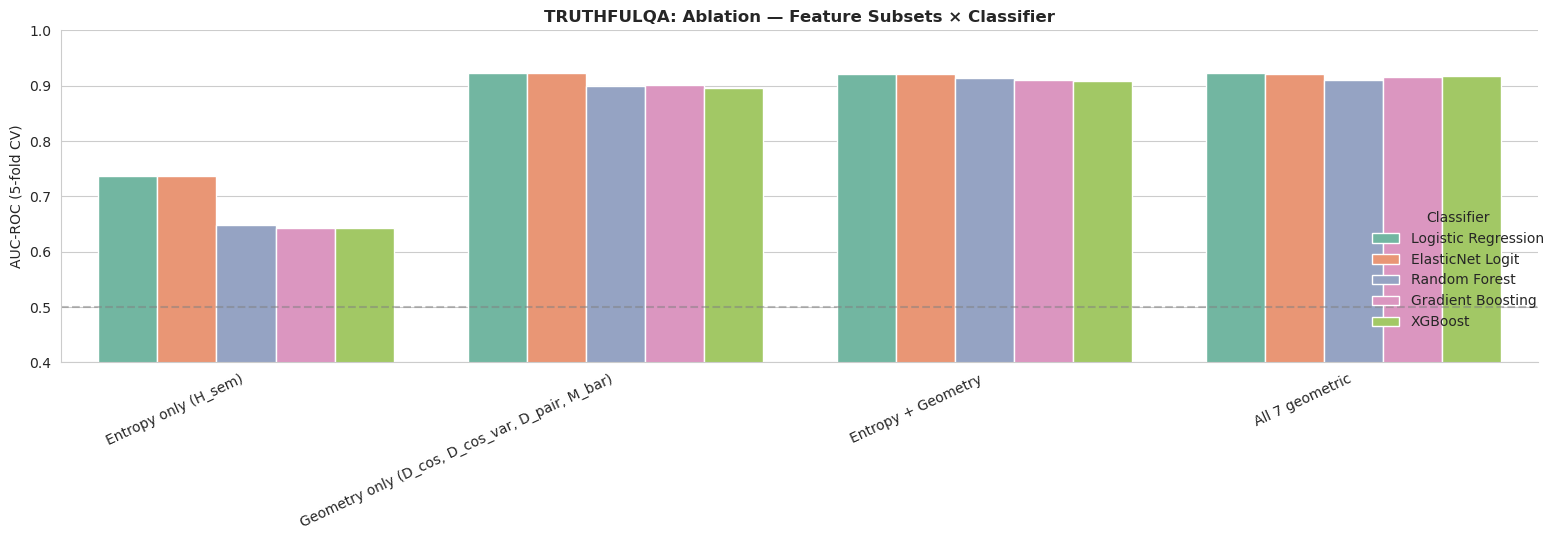

In [38]:
fig = plot_ablation_bar(df_clf_truthfulqa, dataset_name='TRUTHFULQA')
plt.savefig(os.path.join(OUTPUT_DIR, 'truthfulqa_ablation_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRUTHFULQA: Ablation ROC Curves


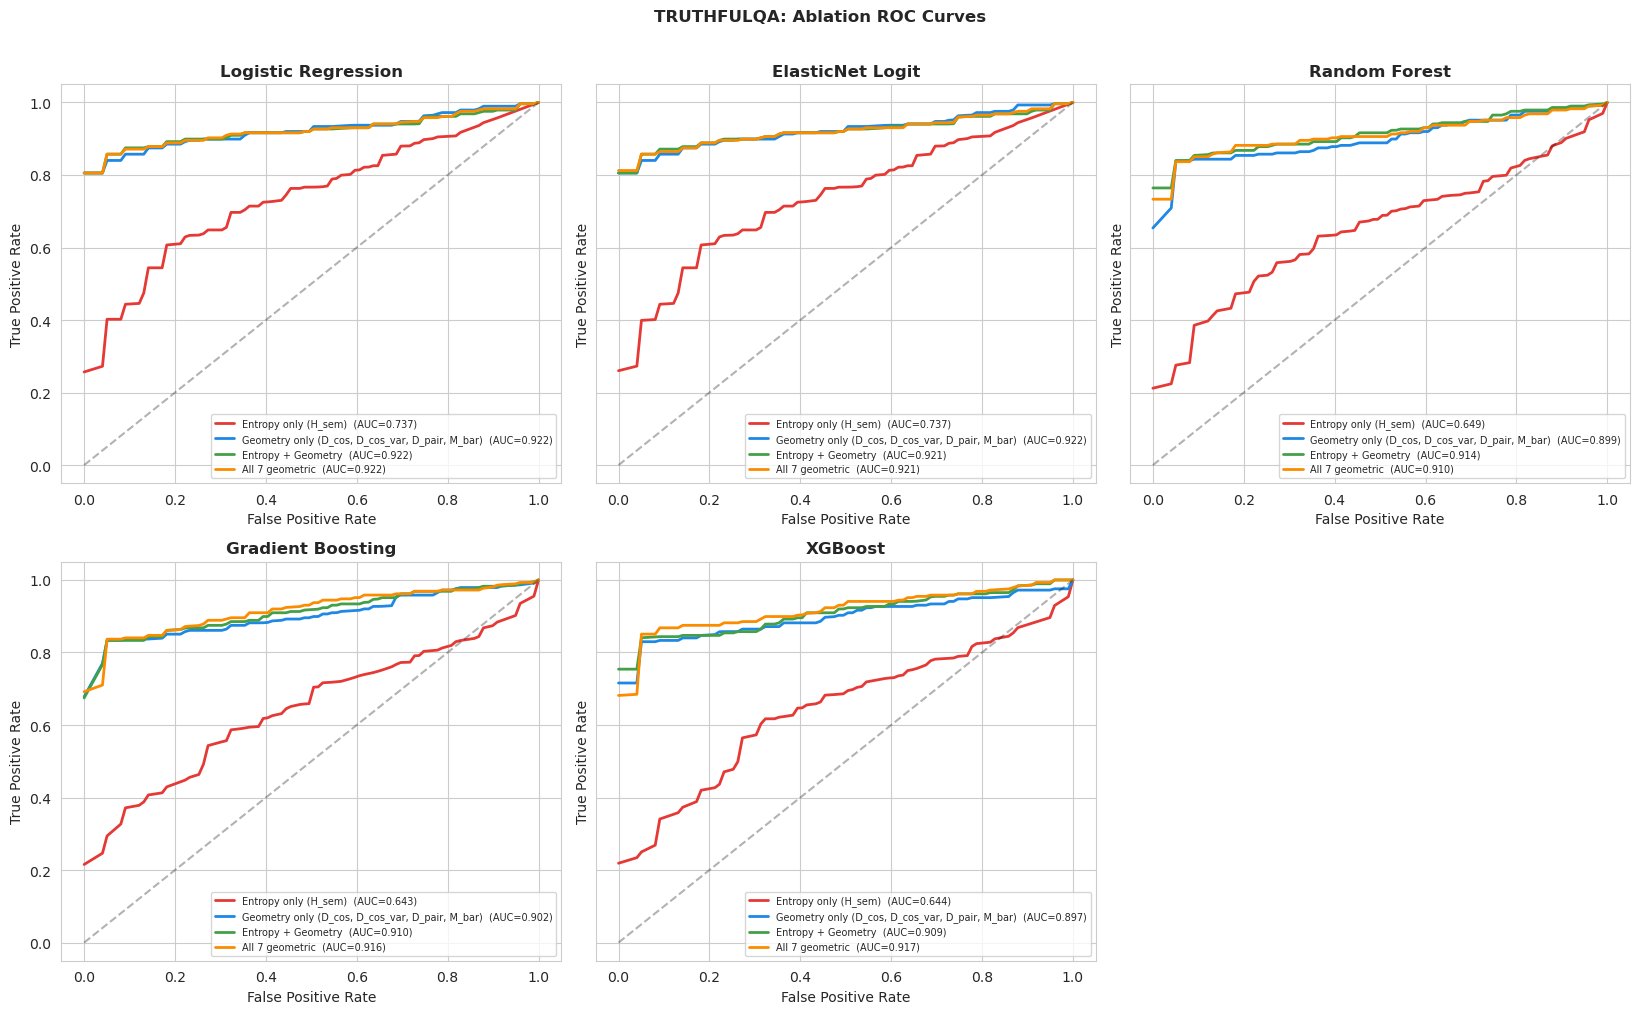

In [39]:
fig = plot_ablation_roc_curves(
    X_tr_truthfulqa, y_tr_truthfulqa,
    classifiers=build_classifiers(RANDOM_SEED),
    ablation_sets={k: ('geo', v) for k, v in ABLATION_SETS.items()},
    dataset_name='TRUTHFULQA', random_seed=RANDOM_SEED,
)
plt.savefig(os.path.join(OUTPUT_DIR, 'truthfulqa_ablation_roc.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRUTHFULQA: Feature-Level ROC Curves


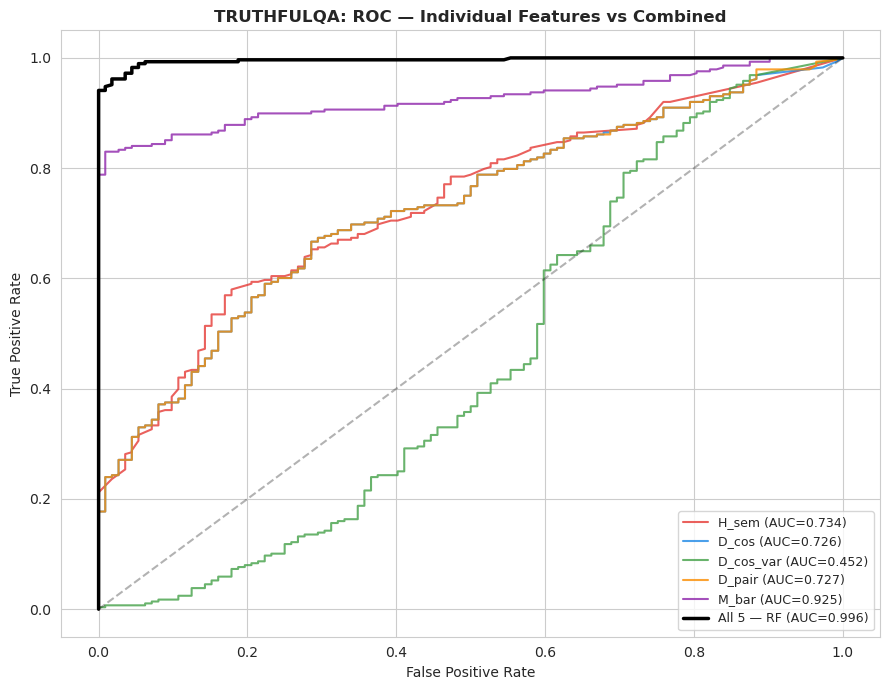

In [40]:
fig = plot_roc_curves(X_tr_truthfulqa, y_tr_truthfulqa, dataset_name='TRUTHFULQA',
                      random_seed=RANDOM_SEED)
plt.savefig(os.path.join(OUTPUT_DIR, 'truthfulqa_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRUTHFULQA: ROC & Precision-Recall



=== TRUTHFULQA — Metrics ({_eval_label_truthfulqa) ===
  roc_auc                   0.9157
  average_precision         0.9719
  brier_score               0.1215
  accuracy_at_0.5           0.8100
  precision_at_0.5          0.8354
  recall_at_0.5             0.9167
  f1_at_0.5                 0.8742


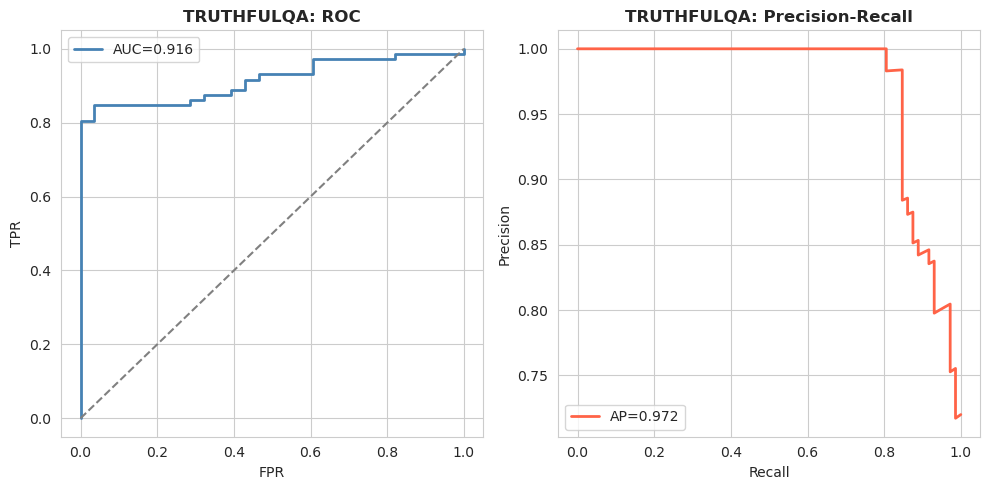

In [41]:
if USE_HOLDOUT:
    _bundle_truthfulqa = evaluate_final_model(
        best_truthfulqa, X_tr_truthfulqa, X_te_truthfulqa,
        y_tr_truthfulqa, y_te_truthfulqa,
        feat_names=GEO_FEATURES, random_seed=RANDOM_SEED,
    )
    _eval_label_truthfulqa = 'hold-out test set'
else:
    _bundle_truthfulqa = evaluate_cv_predictions(
        feat_dfs['truthfulqa'], best_truthfulqa, random_seed=RANDOM_SEED,
    )
    _eval_label_truthfulqa = 'CV out-of-fold'

print(f'\n=== TRUTHFULQA — Metrics ({{_eval_label_truthfulqa) ===')
for k, v in _bundle_truthfulqa['test_metrics'].items():
    print(f'  {k:25s} {v:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
auc_v = _bundle_truthfulqa['test_metrics']['roc_auc']
ap_v  = _bundle_truthfulqa['test_metrics']['average_precision']
axes[0].plot(_bundle_truthfulqa['roc_curve_df']['fpr'],
             _bundle_truthfulqa['roc_curve_df']['tpr'],
             color='steelblue', lw=2, label=f'AUC={auc_v:.3f}')
axes[0].plot([0,1],[0,1],'--',color='gray'); axes[0].legend()
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title(f'TRUTHFULQA: ROC', fontweight='bold')
axes[1].plot(_bundle_truthfulqa['pr_curve_df']['recall'],
             _bundle_truthfulqa['pr_curve_df']['precision'],
             color='tomato', lw=2, label=f'AP={ap_v:.3f}')
axes[1].legend(); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'TRUTHFULQA: Precision-Recall', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'truthfulqa_roc_pr.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRUTHFULQA: Per-Domain Classification

> **Exploratory only.** CV within each domain sub-group. No train/test split within domains — sample counts are too small. See domain validity caveat in eda.ipynb.


Excluded from per-domain classification: ['Entertainment', 'Food & Nutrition', 'Geography', 'History', 'Language', 'Literature', 'Mathematics', 'Other', 'Science', 'Sports']


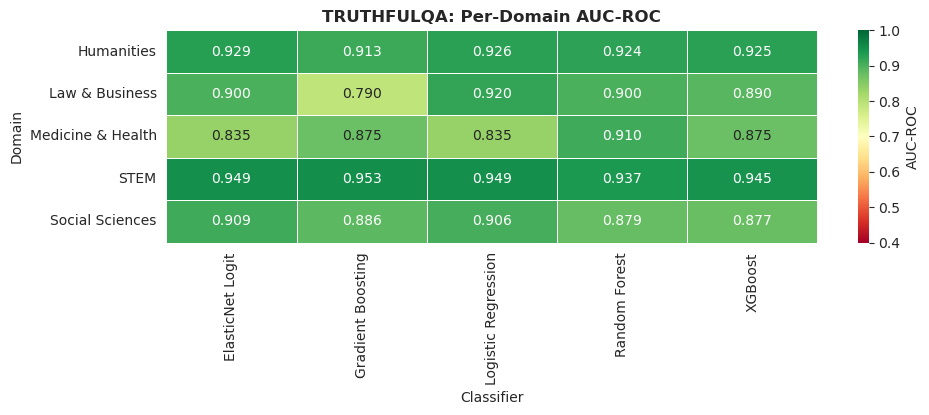

In [42]:
_ad_truthfulqa, _ex_truthfulqa = split_analysis_domains(
    feat_dfs['truthfulqa'], MIN_QUESTIONS_FOR_ANALYSIS, domain_col='domain_canonical',
)
df_dom_truthfulqa = run_per_domain_clf(
    feat_dfs['truthfulqa'], analysis_domains=_ad_truthfulqa,
    excluded_domains=_ex_truthfulqa, domain_col='domain_canonical', random_seed=RANDOM_SEED,
)
df_dom_truthfulqa.to_csv(os.path.join(OUTPUT_DIR, 'truthfulqa_per_domain_clf.csv'), index=False)
fig = plot_per_domain_clf_heatmap(df_dom_truthfulqa, dataset_name='TRUTHFULQA')
plt.savefig(os.path.join(OUTPUT_DIR, 'truthfulqa_per_domain_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRUTHFULQA: SHAP


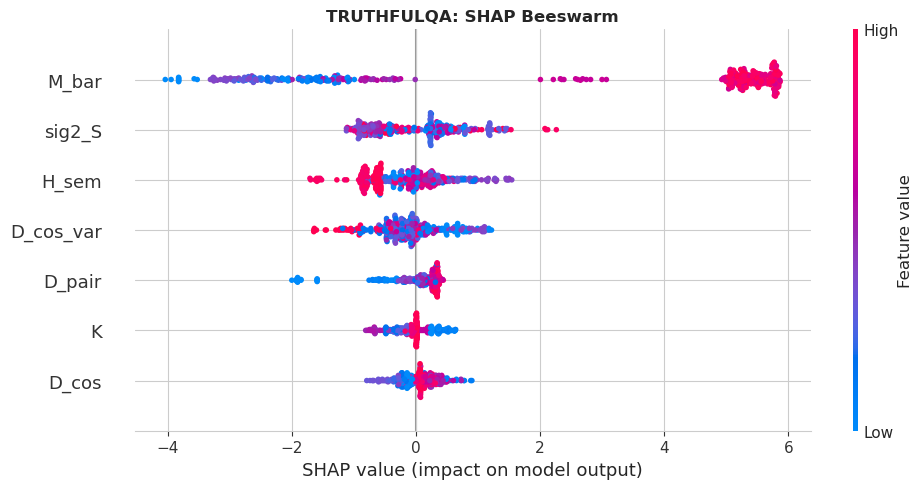

In [43]:
fig = plot_shap_beeswarm(X_tr_truthfulqa, y_tr_truthfulqa,
                         title='TRUTHFULQA: SHAP Beeswarm')
plt.savefig(os.path.join(OUTPUT_DIR, 'truthfulqa_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Combined Dataset — All 2500 Questions


### Combined: Model Selection


In [44]:
if USE_HOLDOUT:
    X_tr_all, X_te_all, y_tr_all, y_te_all, _ = make_train_test_split(
        feat_all, random_seed=RANDOM_SEED,
    )
    df_cv_all, best_all = run_cv_model_selection(
        X_tr_all, y_tr_all, random_seed=RANDOM_SEED,
    )
else:
    df_cv_all, best_all = run_cv_model_selection(feat_all, random_seed=RANDOM_SEED)
display(df_cv_all)


Train: 2000  |  Test: 500
Train hallucination rate: 55.8%
Test  hallucination rate: 55.8%
CV model selection — mode: holdout-train  |  n=2000  |  hallu rate=55.8%
  Logistic Regression       | AUC=0.9164±0.0121  AP=0.9410
  ElasticNet Logit          | AUC=0.9162±0.0121  AP=0.9409
  Random Forest             | AUC=0.9417±0.0068  AP=0.9545
  Gradient Boosting         | AUC=0.9410±0.0096  AP=0.9573
  XGBoost                   | AUC=0.9384±0.0075  AP=0.9553

Best classifier: Random Forest


,Classifier,CV_AUC_mean,CV_AUC_std,CV_AP_mean,CV_AP_std
2,Random Forest,0.941722,0.006786,0.954464,0.005529
3,Gradient Boosting,0.941035,0.009631,0.957269,0.005999
4,XGBoost,0.938448,0.007489,0.955326,0.003955
0,Logistic Regression,0.916359,0.012109,0.941024,0.006058
1,ElasticNet Logit,0.916212,0.012074,0.940935,0.006032


### Combined: Ablation


In [45]:
df_clf_all, X_tr_all, X_te_all, y_tr_all, y_te_all = run_ablation(
    feat_all, random_seed=RANDOM_SEED, use_holdout=USE_HOLDOUT,
)
metric_col = 'Test_AUC' if USE_HOLDOUT else 'CV_AUC_mean'
df_clf_all.to_csv(os.path.join(OUTPUT_DIR, 'combined_ablation.csv'), index=False)
display(df_clf_all.pivot_table(
    index='Variant', columns='Classifier', values=metric_col).round(3))


Train: 2000  |  Test: 500
Train hallucination rate: 55.8%
Test  hallucination rate: 55.8%
Ablation — HOLDOUT MODE  (train=2000, test=500)
  Entropy only (H_sem)                       | Logistic Regression       | CV=0.8574  Test=0.8840
  Entropy only (H_sem)                       | ElasticNet Logit          | CV=0.8574  Test=0.8840
  Entropy only (H_sem)                       | Random Forest             | CV=0.8469  Test=0.8715
  Entropy only (H_sem)                       | Gradient Boosting         | CV=0.8467  Test=0.8730
  Entropy only (H_sem)                       | XGBoost                   | CV=0.8452  Test=0.8623
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Logistic Regression       | CV=0.9014  Test=0.9270
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | ElasticNet Logit          | CV=0.9017  Test=0.9272
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Random Forest             | CV=0.9298  Test=0.9469
  Geometry only (D_cos, D_cos_var, D_pair, M_bar) | Gradient Bo

Classifier,ElasticNet Logit,Gradient Boosting,Logistic Regression,Random Forest,XGBoost
Variant,,,,,
All 7 geometric,0.939,0.961,0.939,0.959,0.962
Entropy + Geometry,0.939,0.962,0.940,0.960,0.957
Entropy only (H_sem),0.884,0.873,0.884,0.871,0.862
"Geometry only (D_cos, D_cos_var, D_pair, M_bar)",0.927,0.945,0.927,0.947,0.944


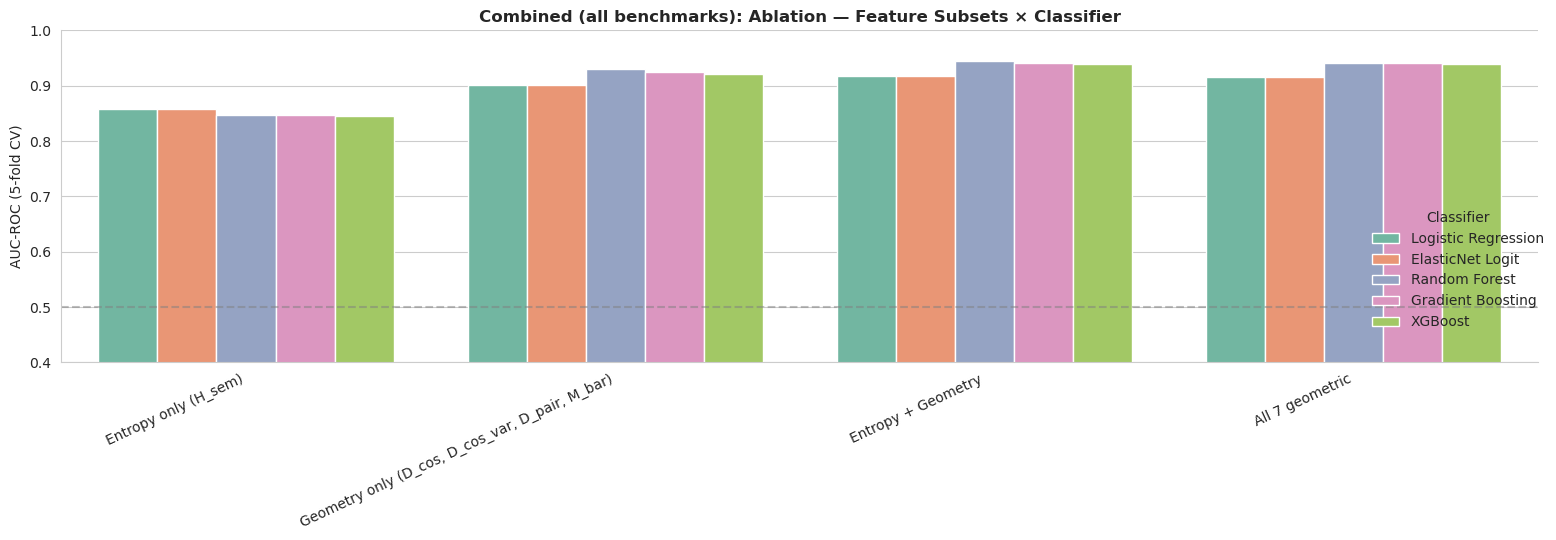

In [46]:
fig = plot_ablation_bar(df_clf_all, dataset_name='Combined (all benchmarks)')
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_ablation_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


### Combined: Ablation ROC Curves


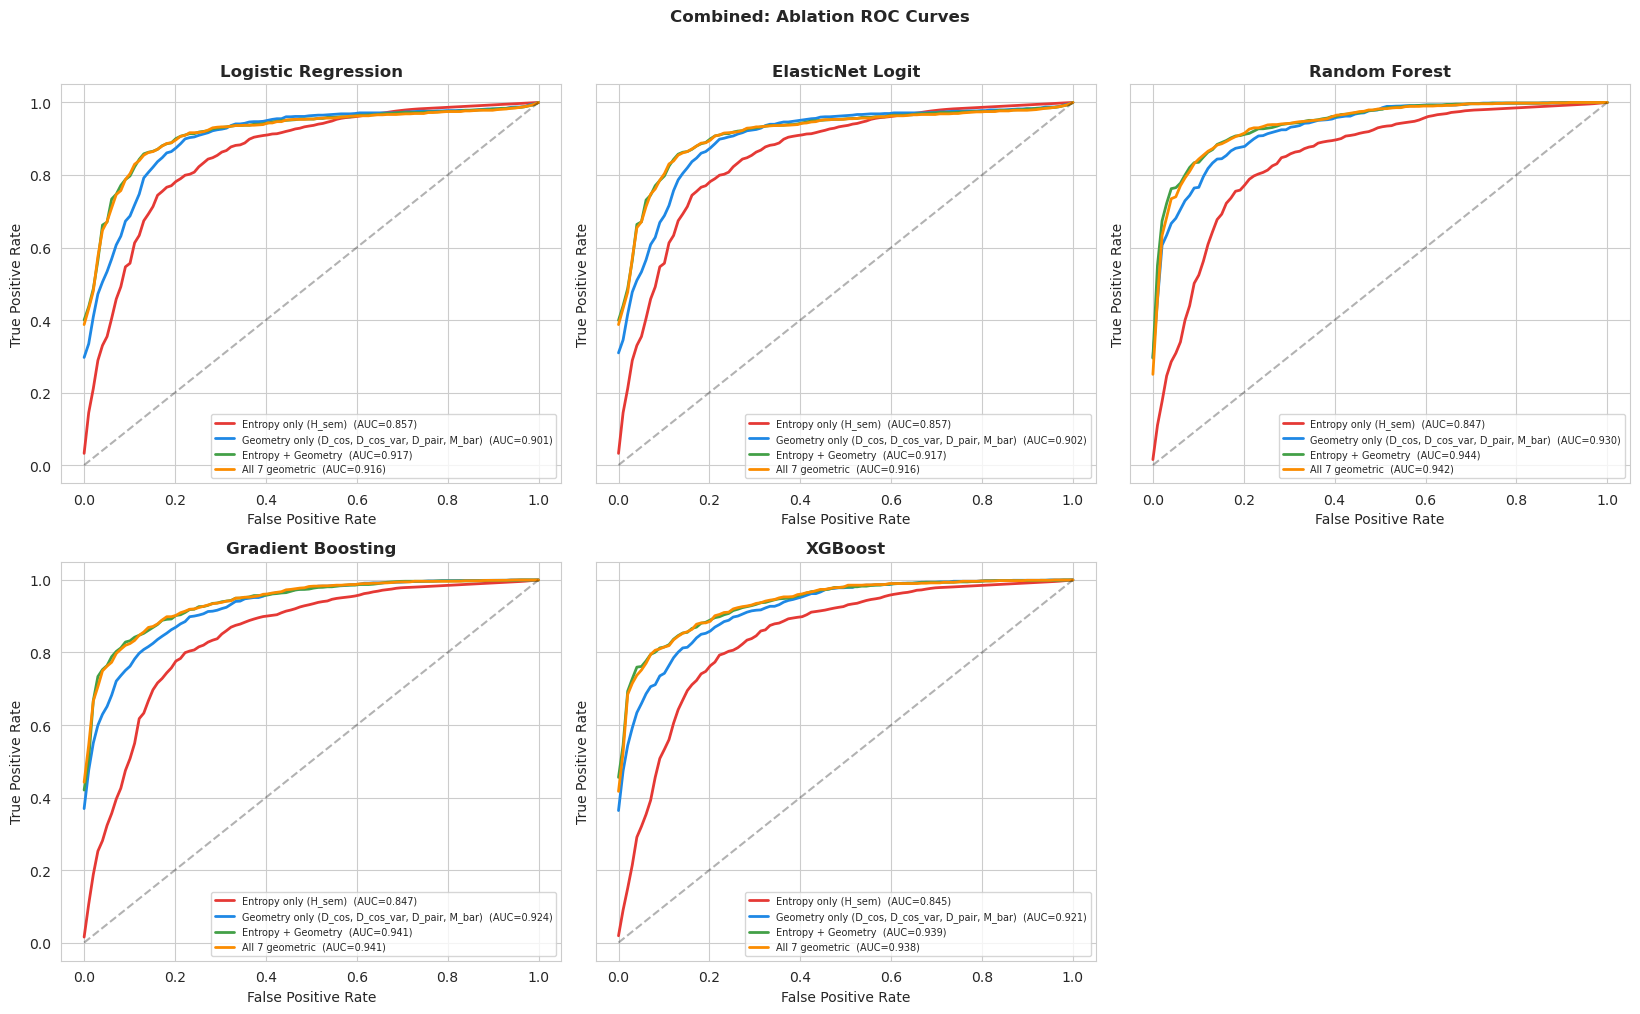

In [47]:
fig = plot_ablation_roc_curves(
    X_tr_all, y_tr_all,
    classifiers=build_classifiers(RANDOM_SEED),
    ablation_sets={k: ('geo', v) for k, v in ABLATION_SETS.items()},
    dataset_name='Combined', random_seed=RANDOM_SEED,
)
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_ablation_roc.png'), dpi=150, bbox_inches='tight')
plt.show()


### Combined: Feature-Level ROC Curves


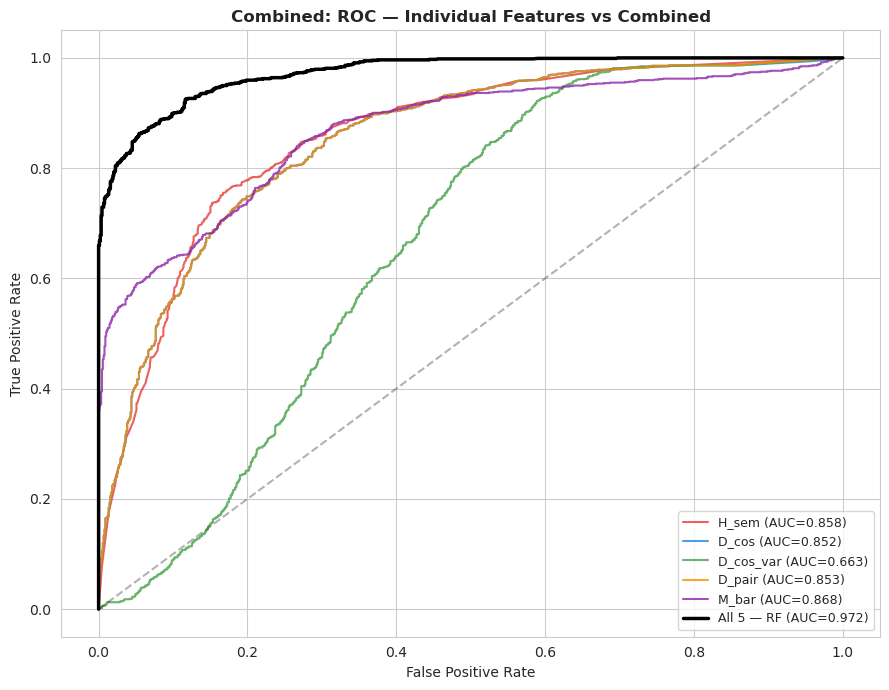

In [48]:
fig = plot_roc_curves(X_tr_all, y_tr_all, dataset_name='Combined', random_seed=RANDOM_SEED)
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_roc_features.png'), dpi=150, bbox_inches='tight')
plt.show()


### Combined: ROC & Precision-Recall



=== Combined — Metrics (hold-out test set) ===
  roc_auc                   0.9593
  average_precision         0.9710
  brier_score               0.0806
  accuracy_at_0.5           0.8960
  precision_at_0.5          0.9097
  recall_at_0.5             0.9032
  f1_at_0.5                 0.9065


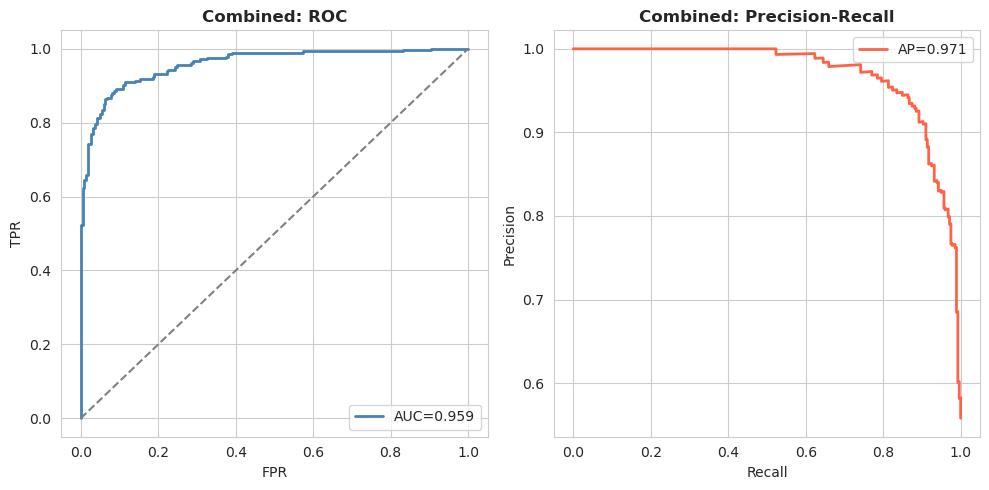

In [49]:
if USE_HOLDOUT:
    bundle_all = evaluate_final_model(
        best_all, X_tr_all, X_te_all, y_tr_all, y_te_all,
        feat_names=GEO_FEATURES, random_seed=RANDOM_SEED,
    )
    _eval_label_all = 'hold-out test set'
else:
    bundle_all = evaluate_cv_predictions(
        feat_all, best_all, random_seed=RANDOM_SEED,
    )
    _eval_label_all = 'CV out-of-fold'

print(f'\n=== Combined — Metrics ({_eval_label_all}) ===')
for k, v in bundle_all['test_metrics'].items():
    print(f'  {k:25s} {v:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
auc_v = bundle_all['test_metrics']['roc_auc']
ap_v  = bundle_all['test_metrics']['average_precision']
axes[0].plot(bundle_all['roc_curve_df']['fpr'], bundle_all['roc_curve_df']['tpr'],
             color='steelblue', lw=2, label=f'AUC={auc_v:.3f}')
axes[0].plot([0,1],[0,1],'--',color='gray'); axes[0].legend()
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Combined: ROC', fontweight='bold')
axes[1].plot(bundle_all['pr_curve_df']['recall'], bundle_all['pr_curve_df']['precision'],
             color='tomato', lw=2, label=f'AP={ap_v:.3f}')
axes[1].legend(); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Combined: Precision-Recall', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_roc_pr.png'), dpi=150, bbox_inches='tight')
plt.show()


### Combined: Calibration, Threshold Diagnostics & Confusion Matrices

These diagnostics are shown **only for the combined dataset** (2500 questions).
At per-benchmark sample sizes (~500 questions, 20% hold-out = 100 test samples),
calibration bins are too sparse for reliable estimates and threshold curves are
noisy. The combined dataset provides a solid 500-sample test set (hold-out mode)
or 2500 out-of-fold predictions (CV mode) for these analyses.


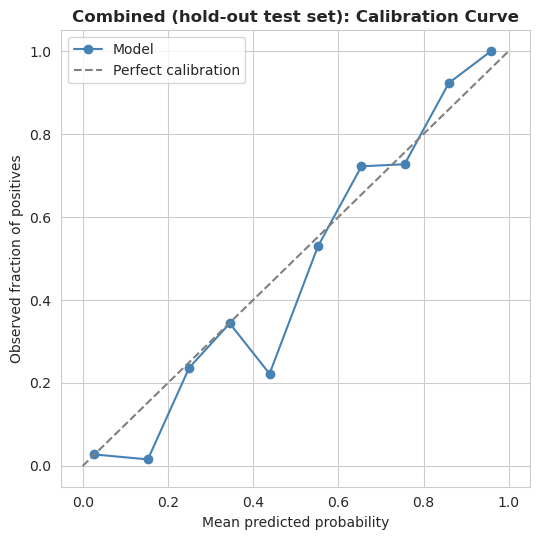

In [50]:
fig = plot_calibration_curve(bundle_all['test_pred_df'],
                             dataset_name=f'Combined ({_eval_label_all})')
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_calibration.png'), dpi=150, bbox_inches='tight')
plt.show()


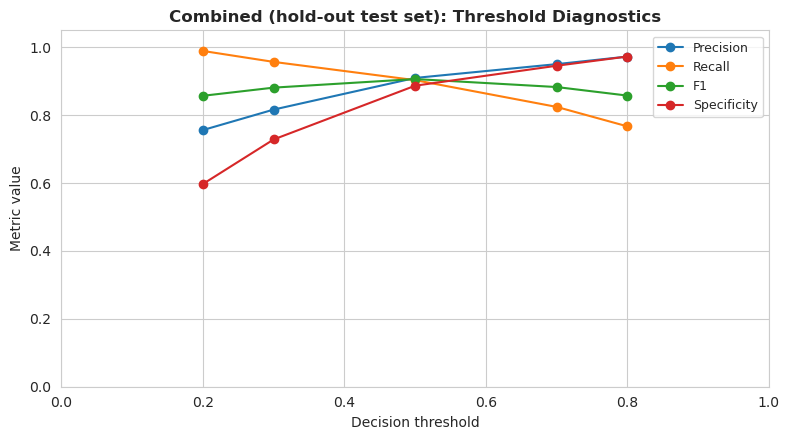

,threshold,accuracy,precision,recall,f1,specificity,tp,fp,tn,fn
0,0.2,0.816,0.756,0.989,0.857,0.597,276,89,132,3
1,0.3,0.856,0.817,0.957,0.881,0.729,267,60,161,12
2,0.5,0.896,0.910,0.903,0.906,0.887,252,25,196,27
3,0.7,0.878,0.950,0.824,0.883,0.946,230,12,209,49
4,0.8,0.858,0.973,0.767,0.858,0.973,214,6,215,65


In [51]:
fig = plot_threshold_diagnostics(bundle_all['threshold_df'],
                                 dataset_name=f'Combined ({_eval_label_all})')
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_threshold_diag.png'), dpi=150, bbox_inches='tight')
plt.show()
display(bundle_all['threshold_df'].round(3))


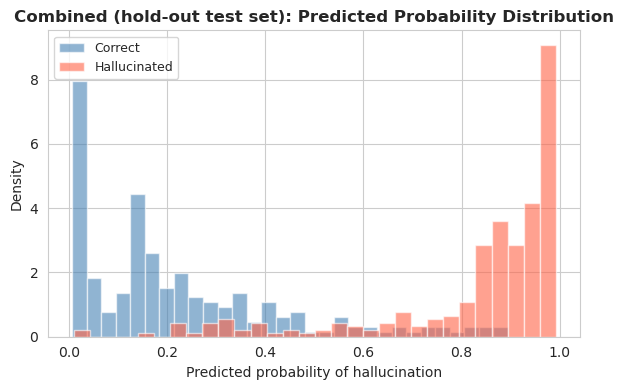

In [52]:
fig = plot_predicted_prob_hist(bundle_all['test_pred_df'],
                              dataset_name=f'Combined ({_eval_label_all})')
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_prob_hist.png'), dpi=150, bbox_inches='tight')
plt.show()


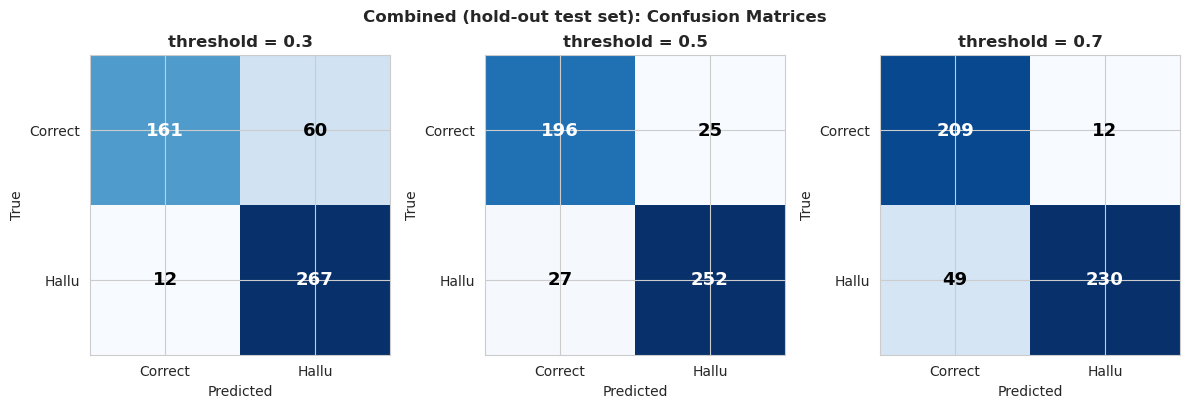

In [53]:
fig = plot_confusion_matrices(bundle_all['test_pred_df'],
                             dataset_name=f'Combined ({_eval_label_all})')
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()


In [54]:
if bundle_all['coef_df'] is not None:
    fig = plot_logit_coefficients(bundle_all['coef_df'], dataset_name='Combined')
    plt.savefig(os.path.join(OUTPUT_DIR, 'combined_coef.png'), dpi=150, bbox_inches='tight')
    plt.show()
    display(bundle_all['coef_df'].round(4))


### Combined: Per-Benchmark Classification


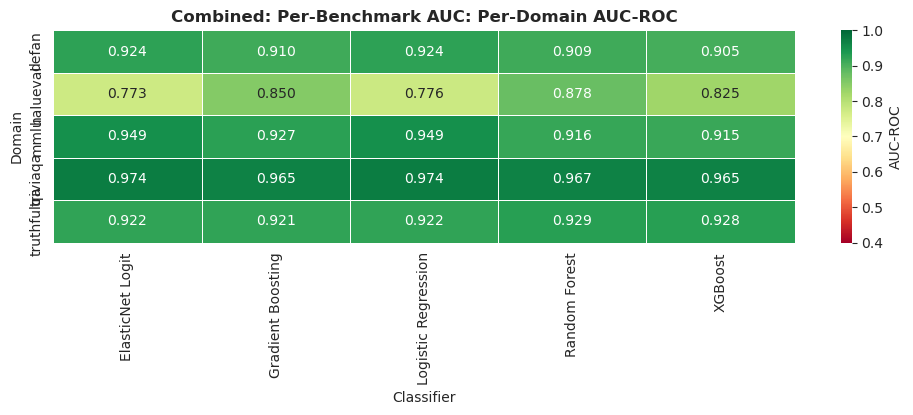

In [55]:
feat_all_tmp = feat_all.copy()
feat_all_tmp['domain'] = feat_all_tmp['dataset']
df_dom_all = run_per_domain_clf(
    feat_all_tmp,
    analysis_domains=sorted(feat_all['dataset'].unique()),
    domain_col='domain', random_seed=RANDOM_SEED,
)
fig = plot_per_domain_clf_heatmap(df_dom_all, dataset_name='Combined: Per-Benchmark AUC')
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_per_dataset_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


### Combined: SHAP


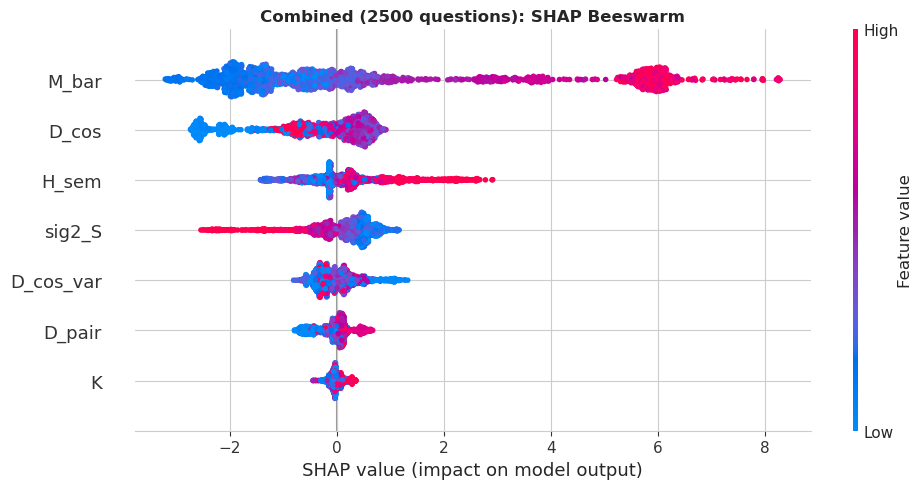

In [56]:
fig = plot_shap_beeswarm(X_tr_all, y_tr_all,
                         title='Combined (2500 questions): SHAP Beeswarm')
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


### Cross-Benchmark Summary


In [57]:
summary = []
metric_col = 'Test_AUC' if USE_HOLDOUT else 'CV_AUC_mean'
for ds in ['defan', 'halueval', 'mmlu', 'triviaqa', 'truthfulqa', 'combined']:
    df_c = pd.read_csv(os.path.join(OUTPUT_DIR, f'{ds}_ablation.csv'))
    best_row = df_c.loc[df_c[metric_col].idxmax()]
    bname = 'all' if ds == 'combined' else ds
    bndl  = eval(f'_bundle_{bname}') if ds != 'combined' else bundle_all
    m = bndl['test_metrics']
    summary.append({
        'Dataset':       ds,
        'Best_Variant':  best_row['Variant'],
        'Best_Clf':      best_row['Classifier'],
        'AUC':           round(m['roc_auc'], 4),
        'Avg_Precision': round(m['average_precision'], 4),
        'Brier':         round(m['brier_score'], 4),
        'F1_at_0.5':     round(m['f1_at_0.5'], 4),
        'Eval_mode':     _eval_label_all if ds == 'combined' else
                         eval(f'_eval_label_{bname}'),
    })
df_summary = pd.DataFrame(summary)
df_summary.to_csv(os.path.join(OUTPUT_DIR, 'training_summary.csv'), index=False)
display(df_summary)


,Dataset,Best_Variant,Best_Clf,AUC,Avg_Precision,Brier,F1_at_0.5,Eval_mode
0,defan,"Geometry only (D_cos, D_cos_var, D_pair, M_bar)",Logistic Regression,0.8953,0.9740,0.1226,0.8846,hold-out test set
1,halueval,Entropy + Geometry,XGBoost,0.9670,0.6624,0.0464,0.4000,hold-out test set
2,mmlu,"Geometry only (D_cos, D_cos_var, D_pair, M_bar)",Logistic Regression,0.9545,0.9879,0.0767,0.9325,hold-out test set
3,triviaqa,Entropy + Geometry,Random Forest,0.9704,0.9430,0.0487,0.9438,hold-out test set
4,truthfulqa,Entropy + Geometry,Random Forest,0.9157,0.9719,0.1215,0.8742,hold-out test set
5,combined,All 7 geometric,XGBoost,0.9593,0.9710,0.0806,0.9065,hold-out test set
